
# Week 5 — Classification Models on Titanic Dataset
## Sami ur Rehman Khan

This notebook covers:
- Logistic Regression
- KNN
- Decision Tree
- Random Forest
- Cross Validation
- ROC/PR Curves
- Dashboard Creation
- Model Saving
- Written Analysis


DATASET LOADED
Dataset Shape: (891, 12)


FIRST 5 ROWS


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S




DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


DESCRIPTIVE STATISTICS


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200




TARGET CLASS DISTRIBUTION


,proportion
Survived,
0,0.616162
1,0.383838



Survived Ratio     : 0.3838
Non-Survived Ratio : 0.6162


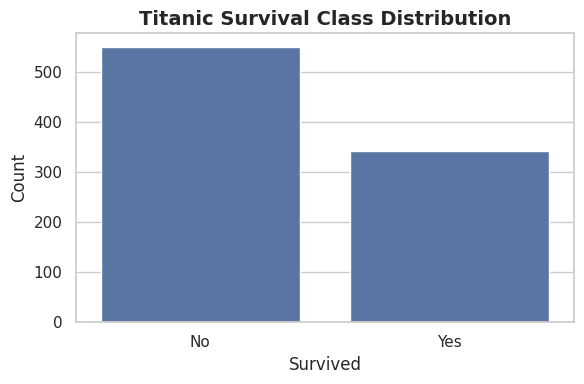



STEP 1 SUMMARY

Completed Tasks:
1. Imported all required libraries
2. Loaded Titanic dataset
3. Displayed dataset overview
4. Examined dataset information
5. Generated descriptive statistics
6. Analyzed target class balance
7. Visualized survival distribution

Saved Figure:
- class_balance.png

The dataset is now ready for preprocessing
and feature engineering.



In [10]:
# =========================================================
# STEP 1 — ENVIRONMENT SETUP & DATASET LOADING
# =========================================================

# ---------------------------------------------------------
# IMPORT LIBRARIES
# ---------------------------------------------------------

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

import time
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold,
    learning_curve
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ---------------------------------------------------------
# VISUAL SETTINGS
# ---------------------------------------------------------

plt.style.use('ggplot')

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# LOAD TITANIC DATASET
# ---------------------------------------------------------

df = pd.read_csv('train.csv')

# ---------------------------------------------------------
# DATASET OVERVIEW
# ---------------------------------------------------------

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)

print(f"Dataset Shape: {df.shape}")

print("\n")

print("=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)

display(df.head())

print("\n")

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print(df.info())

print("\n")

print("=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

display(df.describe())

# ---------------------------------------------------------
# CLASS BALANCE
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("TARGET CLASS DISTRIBUTION")
print("=" * 70)

class_balance = df['Survived'].value_counts(normalize=True)

display(class_balance)

survival_ratio = class_balance[1]
non_survival_ratio = class_balance[0]

print(f"\nSurvived Ratio     : {survival_ratio:.4f}")
print(f"Non-Survived Ratio : {non_survival_ratio:.4f}")

# ---------------------------------------------------------
# VISUALIZE CLASS BALANCE
# ---------------------------------------------------------

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='Survived'
)

plt.title(
    'Titanic Survival Class Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Survived')
plt.ylabel('Count')

plt.xticks(
    [0, 1],
    ['No', 'Yes']
)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'class_balance.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# STEP 1 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 1 SUMMARY")
print("=" * 70)

print("""
Completed Tasks:
1. Imported all required libraries
2. Loaded Titanic dataset
3. Displayed dataset overview
4. Examined dataset information
5. Generated descriptive statistics
6. Analyzed target class balance
7. Visualized survival distribution

Saved Figure:
- class_balance.png

The dataset is now ready for preprocessing
and feature engineering.
""")

In [11]:
# =========================================================
# STEP 2 — FEATURE ENGINEERING & PREPROCESSING
# =========================================================

# ---------------------------------------------------------
# CHECK MISSING VALUES BEFORE PROCESSING
# ---------------------------------------------------------

print("=" * 70)
print("MISSING VALUES BEFORE PREPROCESSING")
print("=" * 70)

display(
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

# ---------------------------------------------------------
# FILL MISSING VALUES
# ---------------------------------------------------------

# Fill Age with median
df['Age'] = df['Age'].fillna(
    df['Age'].median()
)

# Fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

# ---------------------------------------------------------
# FEATURE ENGINEERING
# ---------------------------------------------------------

# Family Size
df['FamilySize'] = (
    df['SibSp'] +
    df['Parch'] + 1
)

# Is Alone
df['IsAlone'] = (
    df['FamilySize'] == 1
).astype(int)

# ---------------------------------------------------------
# LOG TRANSFORM FARE
# ---------------------------------------------------------

df['Fare'] = np.log1p(df['Fare'])

# ---------------------------------------------------------
# ENCODE SEX
# ---------------------------------------------------------

df['Sex'] = df['Sex'].map({
    'male': 1,
    'female': 0
})

# ---------------------------------------------------------
# ONE HOT ENCODE EMBARKED
# ---------------------------------------------------------

df = pd.get_dummies(
    df,
    columns=['Embarked'],
    drop_first=True
)

# ---------------------------------------------------------
# DROP UNUSED COLUMNS
# ---------------------------------------------------------

drop_columns = [
    'PassengerId',
    'Name',
    'Ticket',
    'Cabin'
]

df.drop(
    columns=drop_columns,
    inplace=True
)

# ---------------------------------------------------------
# CONVERT BOOLEAN COLUMNS TO INTEGER
# ---------------------------------------------------------

bool_cols = df.select_dtypes(include='bool').columns

for col in bool_cols:
    df[col] = df[col].astype(int)

# ---------------------------------------------------------
# FINAL VALIDATION
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("FINAL PREPROCESSED DATASET")
print("=" * 70)

print(f"Final Shape: {df.shape}")

print("\n")

print("=" * 70)
print("REMAINING MISSING VALUES")
print("=" * 70)

print(df.isnull().sum().sum())

print("\n")

print("=" * 70)
print("DATA TYPES")
print("=" * 70)

display(df.dtypes.value_counts())

print("\n")

print("=" * 70)
print("FINAL FEATURE PREVIEW")
print("=" * 70)

display(df.head())

# ---------------------------------------------------------
# FEATURE ENGINEERING SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 70)

print("""
Completed Preprocessing Steps:

1. Filled Age missing values with median
2. Filled Embarked missing values with mode
3. Engineered FamilySize feature
4. Engineered IsAlone feature
5. Applied log1p transformation to Fare
6. Encoded Sex column
7. One-hot encoded Embarked
8. Dropped irrelevant columns
9. Converted boolean columns to integers

Engineered Features:
- FamilySize
- IsAlone

The dataset is now fully numerical
and ready for classification modeling.
""")

MISSING VALUES BEFORE PREPROCESSING


,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0




FINAL PREPROCESSED DATASET
Final Shape: (891, 11)


REMAINING MISSING VALUES
0


DATA TYPES


,count
int64,9
float64,2




FINAL FEATURE PREVIEW


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,2.110213,2,0,0,1
1,1,1,0,38.0,1,0,4.280593,2,0,0,0
2,1,3,0,26.0,0,0,2.188856,1,1,0,1
3,1,1,0,35.0,1,0,3.990834,2,0,0,1
4,0,3,1,35.0,0,0,2.202765,1,1,0,1




FEATURE ENGINEERING SUMMARY

Completed Preprocessing Steps:

1. Filled Age missing values with median
2. Filled Embarked missing values with mode
3. Engineered FamilySize feature
4. Engineered IsAlone feature
5. Applied log1p transformation to Fare
6. Encoded Sex column
7. One-hot encoded Embarked
8. Dropped irrelevant columns
9. Converted boolean columns to integers

Engineered Features:
- FamilySize
- IsAlone

The dataset is now fully numerical
and ready for classification modeling.



TRAIN-TEST SPLIT
X_train Shape : (712, 10)
X_test Shape  : (179, 10)

y_train Shape : (712,)
y_test Shape  : (179,)


CLASS DISTRIBUTION — TRAIN SET


,proportion
Survived,
0,0.616573
1,0.383427




CLASS DISTRIBUTION — TEST SET


,proportion
Survived,
0,0.614525
1,0.385475




TRAINING SET SCALING STATISTICS


,Mean,Std
Pclass,-1.821265e-16,1.000703
Sex,-9.979533e-18,1.000703
Age,2.120651e-16,1.000703
SibSp,-5.613487e-18,1.000703
Parch,-1.621674e-17,1.000703
Fare,2.582204e-16,1.000703
FamilySize,3.492836e-17,1.000703
IsAlone,6.985673e-17,1.000703
Embarked_Q,-5.239255e-17,1.000703
Embarked_S,1.496930e-16,1.000703




Average Mean (Train): 0.0
Average Std (Train): 1.0007


TEST SET SCALING STATISTICS


,Mean,Std
Pclass,-0.002072,1.018432
Sex,0.030411,0.993077
Age,-0.037557,0.997234
SibSp,0.141023,1.181375
Parch,-0.052631,0.793024
Fare,0.058190,0.946958
FamilySize,0.066376,1.076343
IsAlone,-0.069963,1.016019
Embarked_Q,0.171014,1.233220
Embarked_S,-0.027950,1.016641




Average Mean (Test): 0.0277
Average Std (Test): 1.0272


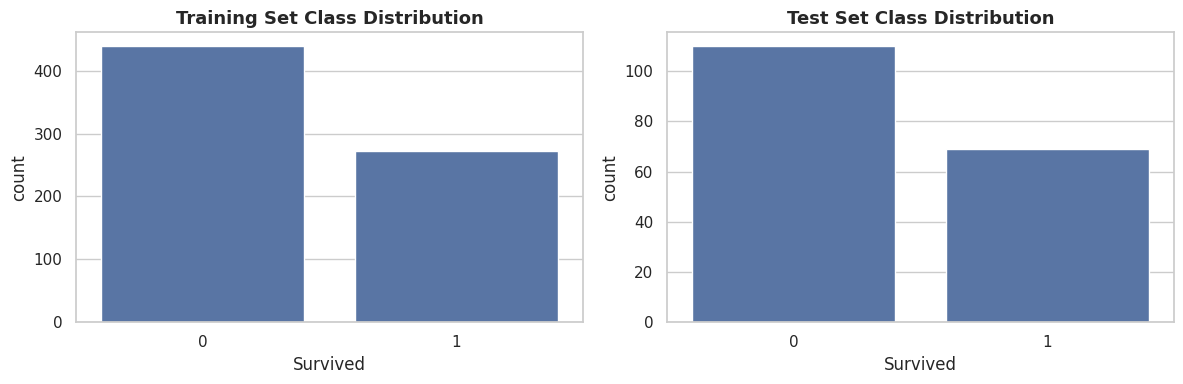



STEP 3 SUMMARY

Completed Tasks:

1. Created feature matrix X and target y
2. Applied train_test_split()
3. Used stratify=y to preserve class balance
4. Applied StandardScaler
5. Fit scaler ONLY on training data
6. Transformed both train and test sets
7. Verified scaling statistics
8. Visualized class balance after split

Saved Figure:
- train_test_class_distribution.png

Key Concept:
Stratification ensures that both training
and test datasets maintain the same class
distribution, which is critical for reliable
classification performance evaluation on
imbalanced datasets.



In [12]:
# =========================================================
# STEP 3 — TRAIN-TEST SPLIT & SCALING
# =========================================================

# ---------------------------------------------------------
# FEATURE MATRIX & TARGET
# ---------------------------------------------------------

X = df.drop('Survived', axis=1)

y = df['Survived']

# ---------------------------------------------------------
# TRAIN TEST SPLIT
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------------------------------------------------
# PRINT SPLIT SHAPES
# ---------------------------------------------------------

print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

print(f"X_train Shape : {X_train.shape}")
print(f"X_test Shape  : {X_test.shape}")

print(f"\ny_train Shape : {y_train.shape}")
print(f"y_test Shape  : {y_test.shape}")

# ---------------------------------------------------------
# VERIFY STRATIFICATION
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("CLASS DISTRIBUTION — TRAIN SET")
print("=" * 70)

train_distribution = y_train.value_counts(normalize=True)

display(train_distribution)

print("\n")

print("=" * 70)
print("CLASS DISTRIBUTION — TEST SET")
print("=" * 70)

test_distribution = y_test.value_counts(normalize=True)

display(test_distribution)

# ---------------------------------------------------------
# STANDARD SCALING
# ---------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

# ---------------------------------------------------------
# VERIFY SCALING STATISTICS
# ---------------------------------------------------------

train_stats = pd.DataFrame({
    'Mean': X_train_scaled.mean(),
    'Std': X_train_scaled.std()
})

test_stats = pd.DataFrame({
    'Mean': X_test_scaled.mean(),
    'Std': X_test_scaled.std()
})

print("\n")

print("=" * 70)
print("TRAINING SET SCALING STATISTICS")
print("=" * 70)

display(train_stats.head(10))

print("\n")

print("Average Mean (Train):",
      round(train_stats['Mean'].mean(), 4))

print("Average Std (Train):",
      round(train_stats['Std'].mean(), 4))

print("\n")

print("=" * 70)
print("TEST SET SCALING STATISTICS")
print("=" * 70)

display(test_stats.head(10))

print("\n")

print("Average Mean (Test):",
      round(test_stats['Mean'].mean(), 4))

print("Average Std (Test):",
      round(test_stats['Std'].mean(), 4))

# ---------------------------------------------------------
# VISUALIZE CLASS BALANCE AFTER SPLIT
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

sns.countplot(
    x=y_train,
    ax=axes[0]
)

axes[0].set_title(
    'Training Set Class Distribution',
    fontsize=13,
    fontweight='bold'
)

sns.countplot(
    x=y_test,
    ax=axes[1]
)

axes[1].set_title(
    'Test Set Class Distribution',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'train_test_class_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# STEP 3 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 3 SUMMARY")
print("=" * 70)

print("""
Completed Tasks:

1. Created feature matrix X and target y
2. Applied train_test_split()
3. Used stratify=y to preserve class balance
4. Applied StandardScaler
5. Fit scaler ONLY on training data
6. Transformed both train and test sets
7. Verified scaling statistics
8. Visualized class balance after split

Saved Figure:
- train_test_class_distribution.png

Key Concept:
Stratification ensures that both training
and test datasets maintain the same class
distribution, which is critical for reliable
classification performance evaluation on
imbalanced datasets.
""")

In [13]:
# =========================================================
# STEP 4 — CLASSIFICATION EVALUATION UTILITIES
# =========================================================

# ---------------------------------------------------------
# IMPORT ADDITIONAL METRICS
# ---------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ---------------------------------------------------------
# GLOBAL RESULTS STORAGE
# ---------------------------------------------------------

classification_results = []

# =========================================================
# FUNCTION 1 — evaluate_classifier()
# =========================================================

def evaluate_classifier(
    y_true: pd.Series,
    y_pred: np.ndarray,
    y_prob: np.ndarray,
    model_name: str
) -> dict:
    """
    Evaluates classification model performance using
    multiple classification metrics.

    Parameters
    ----------
    y_true : pd.Series
        Actual target values.

    y_pred : np.ndarray
        Predicted class labels.

    y_prob : np.ndarray
        Predicted probabilities for positive class.

    model_name : str
        Name of the classification model.

    Returns
    -------
    dict
        Dictionary containing all evaluation metrics.
    """

    # -----------------------------------------------------
    # METRIC CALCULATIONS
    # -----------------------------------------------------

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred)

    recall = recall_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred)

    auc = roc_auc_score(y_true, y_prob)

    # -----------------------------------------------------
    # PRINT RESULTS
    # -----------------------------------------------------

    print("=" * 70)
    print(f"MODEL EVALUATION — {model_name}")
    print("=" * 70)

    print(f"Accuracy   : {accuracy:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 Score   : {f1:.4f}")
    print(f"ROC AUC    : {auc:.4f}")

    # -----------------------------------------------------
    # CLASSIFICATION REPORT
    # -----------------------------------------------------

    print("\n")

    print("=" * 70)
    print("CLASSIFICATION REPORT")
    print("=" * 70)

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    # -----------------------------------------------------
    # STORE RESULTS
    # -----------------------------------------------------

    results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'ROC_AUC': auc
    }

    classification_results.append(results)

    return results

# =========================================================
# FUNCTION 2 — plot_confusion_matrix_custom()
# =========================================================

def plot_confusion_matrix_custom(
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str
) -> None:
    """
    Creates a confusion matrix heatmap for a
    classification model.

    Parameters
    ----------
    y_true : pd.Series
        Actual target labels.

    y_pred : np.ndarray
        Predicted class labels.

    model_name : str
        Name of classification model.

    Returns
    -------
    None
    """

    # -----------------------------------------------------
    # COMPUTE CONFUSION MATRIX
    # -----------------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    # -----------------------------------------------------
    # PLOT
    # -----------------------------------------------------

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(
        f'Confusion Matrix — {model_name}',
        fontsize=14,
        fontweight='bold'
    )

    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')

    plt.tight_layout()

    # -----------------------------------------------------
    # SAVE FIGURE
    # -----------------------------------------------------

    filename = (
        model_name
        .lower()
        .replace(" ", "_")
        + '_confusion_matrix.png'
    )

    plt.savefig(
        filename,
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

# =========================================================
# FUNCTION 3 — plot_roc_curve_custom()
# =========================================================

def plot_roc_curve_custom(
    y_true: pd.Series,
    y_prob: np.ndarray,
    model_name: str
) -> None:
    """
    Plots ROC Curve for classification model.

    Parameters
    ----------
    y_true : pd.Series
        Actual target labels.

    y_prob : np.ndarray
        Predicted probabilities.

    model_name : str
        Name of classification model.

    Returns
    -------
    None
    """

    # -----------------------------------------------------
    # COMPUTE ROC CURVE
    # -----------------------------------------------------

    fpr, tpr, _ = roc_curve(
        y_true,
        y_prob
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    # -----------------------------------------------------
    # PLOT
    # -----------------------------------------------------

    plt.figure(figsize=(6, 5))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'AUC = {auc:.4f}'
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle='--'
    )

    plt.title(
        f'ROC Curve — {model_name}',
        fontsize=14,
        fontweight='bold'
    )

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    # -----------------------------------------------------
    # SAVE FIGURE
    # -----------------------------------------------------

    filename = (
        model_name
        .lower()
        .replace(" ", "_")
        + '_roc_curve.png'
    )

    plt.savefig(
        filename,
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

# =========================================================
# FUNCTION TEST
# =========================================================

print("=" * 70)
print("FUNCTIONS CREATED SUCCESSFULLY")
print("=" * 70)

print("""
Created Functions:

1. evaluate_classifier()
   -> Computes classification metrics

2. plot_confusion_matrix_custom()
   -> Creates confusion matrix heatmap

3. plot_roc_curve_custom()
   -> Creates ROC curve visualization

Metrics Included:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

All functions include:
- Type hints
- Complete docstrings
- Figure saving support
- Reusable workflow design
""")

FUNCTIONS CREATED SUCCESSFULLY

Created Functions:

1. evaluate_classifier()
   -> Computes classification metrics

2. plot_confusion_matrix_custom()
   -> Creates confusion matrix heatmap

3. plot_roc_curve_custom()
   -> Creates ROC curve visualization

Metrics Included:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

All functions include:
- Type hints
- Complete docstrings
- Figure saving support
- Reusable workflow design



LOGISTIC REGRESSION MODEL TRAINED


MODEL EVALUATION — Logistic Regression (Train)
Accuracy   : 0.7963
Precision  : 0.7481
Recall     : 0.7070
F1 Score   : 0.7269
ROC AUC    : 0.8661


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       439
           1       0.75      0.71      0.73       273

    accuracy                           0.80       712
   macro avg       0.79      0.78      0.78       712
weighted avg       0.79      0.80      0.80       712



MODEL EVALUATION — Logistic Regression (Test)
Accuracy   : 0.8212
Precision  : 0.8033
Recall     : 0.7101
F1 Score   : 0.7538
ROC AUC    : 0.8448


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.8

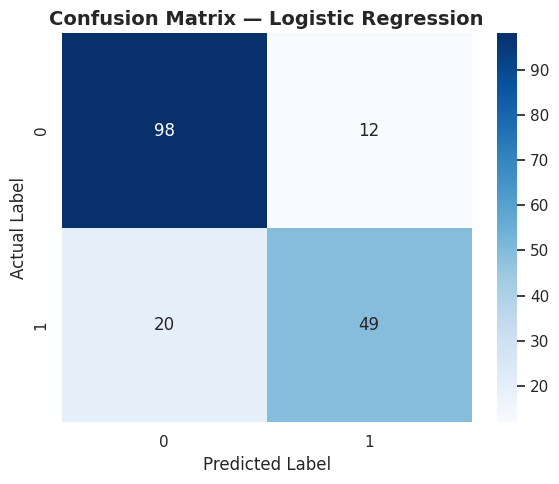

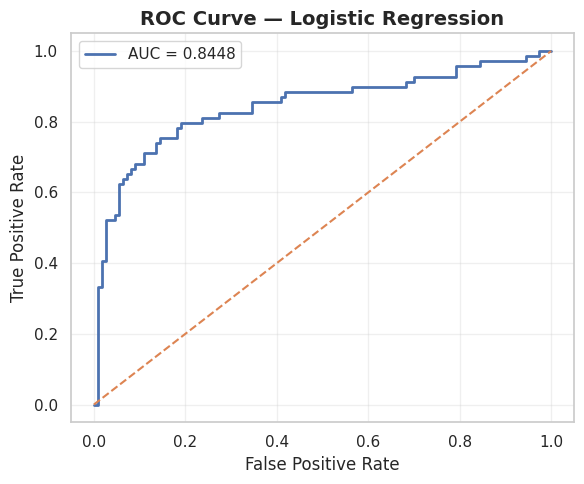



TOP 10 MOST INFLUENTIAL FEATURES


,Feature,Coefficient
1,Sex,-1.226255
0,Pclass,-0.725153
2,Age,-0.498059
5,Fare,0.366844
3,SibSp,-0.321390
6,FamilySize,-0.260763
7,IsAlone,-0.244882
8,Embarked_Q,0.117592
9,Embarked_S,-0.106621
4,Parch,-0.087646


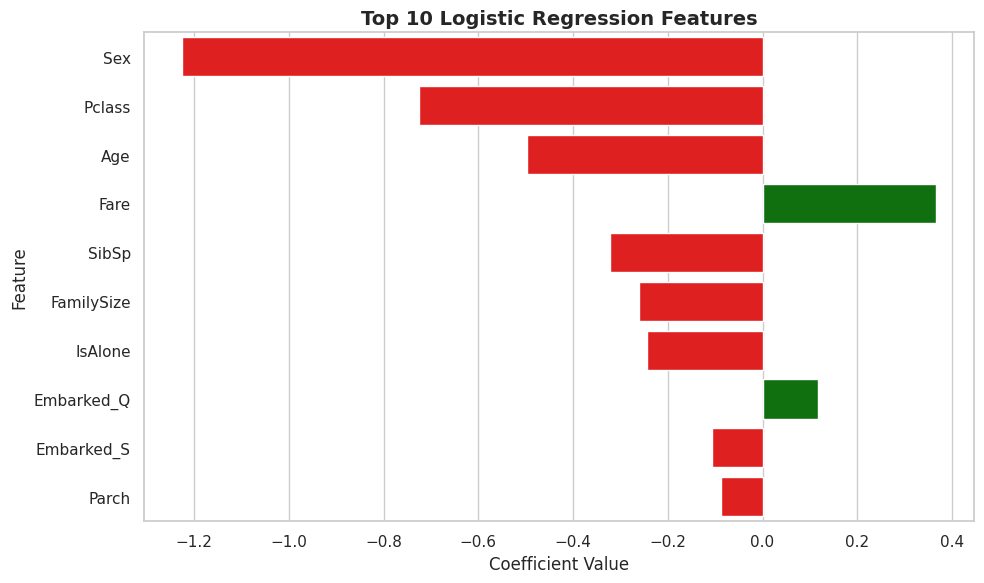



THRESHOLD ANALYSIS


,Threshold,Precision,Recall,F1_Score
0,0.3,0.666667,0.811594,0.732026
1,0.4,0.722222,0.753623,0.737589
2,0.5,0.803279,0.710145,0.753846
3,0.6,0.862745,0.637681,0.733333
4,0.7,0.900000,0.521739,0.660550




BEST THRESHOLD
Best Threshold : 0.5
Best F1 Score  : 0.7538


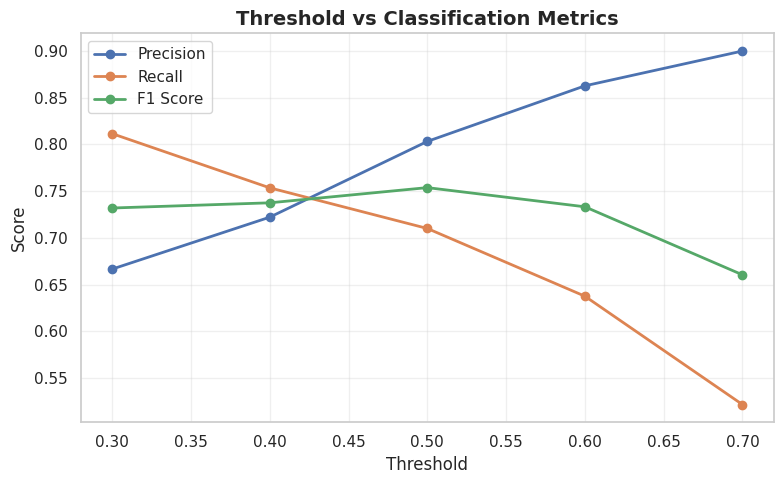



INTERPRETATION

The best F1 score was achieved at
threshold = 0.5.

Lower thresholds generally:
- increase Recall
- decrease Precision

Higher thresholds generally:
- increase Precision
- decrease Recall

In applications such as disease detection,
a lower threshold is often preferred because
missing a true positive case can be much
more dangerous than producing false alarms.



STEP 5 SUMMARY

Completed Tasks:

1. Trained Logistic Regression model
2. Generated train and test predictions
3. Evaluated classification metrics
4. Created confusion matrix
5. Generated ROC curve
6. Analyzed feature coefficients
7. Compared decision thresholds
8. Identified optimal F1 threshold

Saved Figures:
- logistic_regression_confusion_matrix.png
- logistic_regression_roc_curve.png
- logistic_feature_importance.png
- threshold_analysis.png

Logistic Regression now serves as the
baseline classifier for future models.



In [14]:
# =========================================================
# STEP 5 — BASELINE MODEL: LOGISTIC REGRESSION
# =========================================================

# ---------------------------------------------------------
# TRAIN LOGISTIC REGRESSION MODEL
# ---------------------------------------------------------

logistic_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("=" * 70)
print("LOGISTIC REGRESSION MODEL TRAINED")
print("=" * 70)

# ---------------------------------------------------------
# TRAIN PREDICTIONS
# ---------------------------------------------------------

y_train_pred_log = logistic_model.predict(
    X_train_scaled
)

y_train_prob_log = logistic_model.predict_proba(
    X_train_scaled
)[:, 1]

# ---------------------------------------------------------
# TEST PREDICTIONS
# ---------------------------------------------------------

y_test_pred_log = logistic_model.predict(
    X_test_scaled
)

y_test_prob_log = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

# ---------------------------------------------------------
# TRAIN EVALUATION
# ---------------------------------------------------------

print("\n")

train_results_log = evaluate_classifier(
    y_true=y_train,
    y_pred=y_train_pred_log,
    y_prob=y_train_prob_log,
    model_name="Logistic Regression (Train)"
)

# ---------------------------------------------------------
# TEST EVALUATION
# ---------------------------------------------------------

print("\n")

test_results_log = evaluate_classifier(
    y_true=y_test,
    y_pred=y_test_pred_log,
    y_prob=y_test_prob_log,
    model_name="Logistic Regression (Test)"
)

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_log,
    model_name="Logistic Regression"
)

# ---------------------------------------------------------
# ROC CURVE
# ---------------------------------------------------------

plot_roc_curve_custom(
    y_true=y_test,
    y_prob=y_test_prob_log,
    model_name="Logistic Regression"
)

# ---------------------------------------------------------
# FEATURE IMPORTANCE ANALYSIS
# ---------------------------------------------------------

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logistic_model.coef_[0]
})

coefficients['Abs_Coefficient'] = (
    coefficients['Coefficient'].abs()
)

top_features = coefficients.sort_values(
    by='Abs_Coefficient',
    ascending=False
).head(10)

print("\n")

print("=" * 70)
print("TOP 10 MOST INFLUENTIAL FEATURES")
print("=" * 70)

display(
    top_features[
        ['Feature', 'Coefficient']
    ]
)

# ---------------------------------------------------------
# VISUALIZE FEATURE IMPORTANCE
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

colors = [
    'green' if x > 0 else 'red'
    for x in top_features['Coefficient']
]

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature',
    palette=colors
)

plt.title(
    'Top 10 Logistic Regression Features',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Coefficient Value')
plt.ylabel('Feature')

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'logistic_feature_importance.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# THRESHOLD ANALYSIS
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("THRESHOLD ANALYSIS")
print("=" * 70)

threshold_results = []

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    y_pred_threshold = (
        y_test_prob_log >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold
    )

    recall = recall_score(
        y_test,
        y_pred_threshold
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold
    )

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

# ---------------------------------------------------------
# BEST THRESHOLD
# ---------------------------------------------------------

best_threshold_row = threshold_df.loc[
    threshold_df['F1_Score'].idxmax()
]

best_threshold = best_threshold_row['Threshold']

best_f1 = best_threshold_row['F1_Score']

print("\n")

print("=" * 70)
print("BEST THRESHOLD")
print("=" * 70)

print(f"Best Threshold : {best_threshold}")
print(f"Best F1 Score  : {best_f1:.4f}")

# ---------------------------------------------------------
# THRESHOLD VISUALIZATION
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='o',
    linewidth=2,
    label='Precision'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    linewidth=2,
    label='Recall'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1_Score'],
    marker='o',
    linewidth=2,
    label='F1 Score'
)

plt.title(
    'Threshold vs Classification Metrics',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Threshold')
plt.ylabel('Score')

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'threshold_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# INTERPRETATION
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print(f"""
The best F1 score was achieved at
threshold = {best_threshold}.

Lower thresholds generally:
- increase Recall
- decrease Precision

Higher thresholds generally:
- increase Precision
- decrease Recall

In applications such as disease detection,
a lower threshold is often preferred because
missing a true positive case can be much
more dangerous than producing false alarms.
""")

# ---------------------------------------------------------
# STEP 5 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 5 SUMMARY")
print("=" * 70)

print("""
Completed Tasks:

1. Trained Logistic Regression model
2. Generated train and test predictions
3. Evaluated classification metrics
4. Created confusion matrix
5. Generated ROC curve
6. Analyzed feature coefficients
7. Compared decision thresholds
8. Identified optimal F1 threshold

Saved Figures:
- logistic_regression_confusion_matrix.png
- logistic_regression_roc_curve.png
- logistic_feature_importance.png
- threshold_analysis.png

Logistic Regression now serves as the
baseline classifier for future models.
""")

KNN PERFORMANCE ACROSS DIFFERENT K VALUES


KNN RESULTS


,K,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,1,0.709497,0.623188,0.623188,0.623188,0.693412
1,2,0.754190,0.804878,0.478261,0.600000,0.808300
2,3,0.782123,0.727273,0.695652,0.711111,0.822596
3,4,0.804469,0.840000,0.608696,0.705882,0.832016
4,5,0.782123,0.734375,0.681159,0.706767,0.818248




BEST K VALUE
Best K        : 29
Best F1 Score : 0.7727


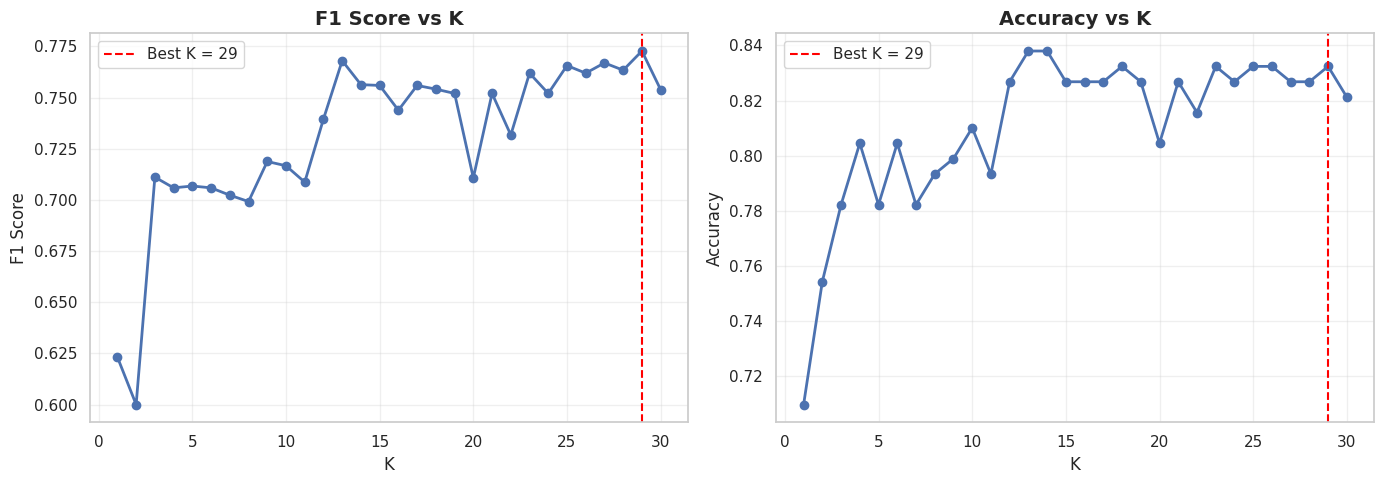



GRID SEARCH CV — KNN
Best K (GridSearchCV): 3
Best CV F1 Score    : 0.7570


DISTANCE METRIC COMPARISON


,Metric,F1_Score,ROC_AUC
0,euclidean,0.772727,0.830501
1,manhattan,0.725926,0.819499
2,minkowski,0.772727,0.830501




BEST DISTANCE METRIC
Best Metric : euclidean


MODEL EVALUATION — Best KNN
Accuracy   : 0.8324
Precision  : 0.8095
Recall     : 0.7391
F1 Score   : 0.7727
ROC AUC    : 0.8305


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       110
           1       0.81      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



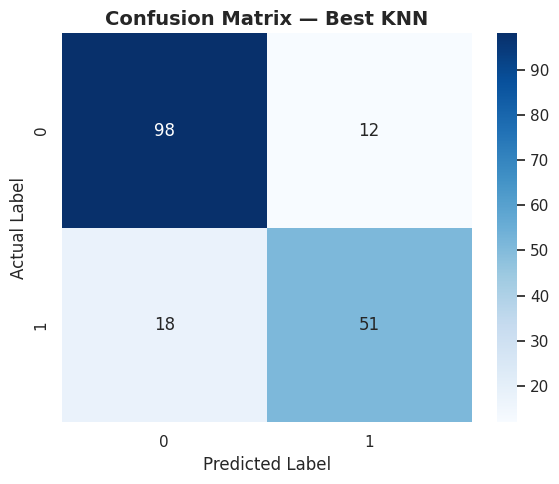

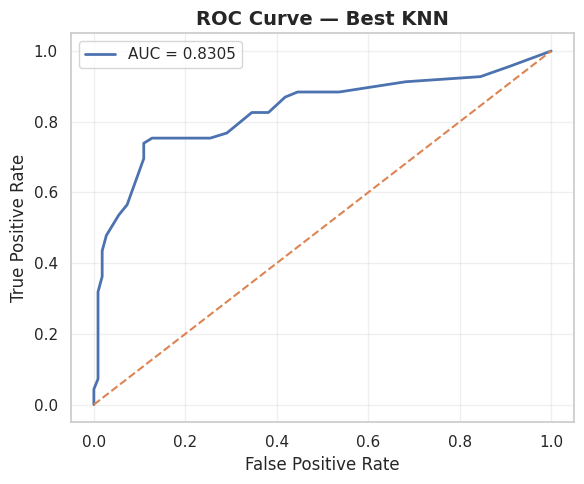



INTERPRETATION

The optimal K value was 29,
which achieved the highest F1 score.

Small K values:
- may overfit
- are sensitive to noise

Large K values:
- smooth predictions
- may underfit

Distance metric performance showed that:
'euclidean' produced the strongest
overall classification performance.



STEP 6 SUMMARY

Completed Tasks:

1. Trained KNN models for K=1 to 30
2. Compared Accuracy, Precision, Recall, F1
3. Identified optimal K value
4. Visualized K-performance relationship
5. Used GridSearchCV for tuning
6. Compared distance metrics
7. Evaluated best KNN classifier
8. Generated confusion matrix & ROC curve

Saved Figures:
- knn_k_analysis.png
- best_knn_confusion_matrix.png
- best_knn_roc_curve.png

KNN classification performance depends
heavily on both:
- neighborhood size (K)
- distance metric selection



In [15]:
# =========================================================
# STEP 6 — KNN: K SELECTION & DISTANCE METRIC COMPARISON
# =========================================================

# ---------------------------------------------------------
# IMPORT KNN
# ---------------------------------------------------------

from sklearn.neighbors import KNeighborsClassifier

# ---------------------------------------------------------
# K VALUE EXPERIMENTATION
# ---------------------------------------------------------

knn_results = []

k_values = range(1, 31)

print("=" * 70)
print("KNN PERFORMANCE ACROSS DIFFERENT K VALUES")
print("=" * 70)

for k in k_values:

    knn_model = KNeighborsClassifier(
        n_neighbors=k
    )

    knn_model.fit(
        X_train_scaled,
        y_train
    )

    # Predictions
    y_pred_knn = knn_model.predict(
        X_test_scaled
    )

    y_prob_knn = knn_model.predict_proba(
        X_test_scaled
    )[:, 1]

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred_knn
    )

    precision = precision_score(
        y_test,
        y_pred_knn
    )

    recall = recall_score(
        y_test,
        y_pred_knn
    )

    f1 = f1_score(
        y_test,
        y_pred_knn
    )

    auc = roc_auc_score(
        y_test,
        y_prob_knn
    )

    # Store Results
    knn_results.append({
        'K': k,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'ROC_AUC': auc
    })

# ---------------------------------------------------------
# RESULTS DATAFRAME
# ---------------------------------------------------------

knn_results_df = pd.DataFrame(
    knn_results
)

print("\n")

print("=" * 70)
print("KNN RESULTS")
print("=" * 70)

display(knn_results_df.head())

# ---------------------------------------------------------
# BEST K
# ---------------------------------------------------------

best_knn_row = knn_results_df.loc[
    knn_results_df['F1_Score'].idxmax()
]

best_k = int(best_knn_row['K'])

best_knn_f1 = best_knn_row['F1_Score']

print("\n")

print("=" * 70)
print("BEST K VALUE")
print("=" * 70)

print(f"Best K        : {best_k}")
print(f"Best F1 Score : {best_knn_f1:.4f}")

# ---------------------------------------------------------
# VISUALIZATION
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# ---------------------------------------------------------
# F1 SCORE VS K
# ---------------------------------------------------------

axes[0].plot(
    knn_results_df['K'],
    knn_results_df['F1_Score'],
    marker='o',
    linewidth=2
)

axes[0].axvline(
    best_k,
    linestyle='--',
    color='red',
    label=f'Best K = {best_k}'
)

axes[0].set_title(
    'F1 Score vs K',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('K')
axes[0].set_ylabel('F1 Score')

axes[0].legend()

axes[0].grid(alpha=0.3)

# ---------------------------------------------------------
# ACCURACY VS K
# ---------------------------------------------------------

axes[1].plot(
    knn_results_df['K'],
    knn_results_df['Accuracy'],
    marker='o',
    linewidth=2
)

axes[1].axvline(
    best_k,
    linestyle='--',
    color='red',
    label=f'Best K = {best_k}'
)

axes[1].set_title(
    'Accuracy vs K',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('K')
axes[1].set_ylabel('Accuracy')

axes[1].legend()

axes[1].grid(alpha=0.3)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'knn_k_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# GRID SEARCH CV
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("GRID SEARCH CV — KNN")
print("=" * 70)

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {
        'n_neighbors': range(1, 30)
    },
    cv=5,
    scoring='f1'
)

knn_grid.fit(
    X_train_scaled,
    y_train
)

print(f"Best K (GridSearchCV): {knn_grid.best_params_['n_neighbors']}")
print(f"Best CV F1 Score    : {knn_grid.best_score_:.4f}")

# ---------------------------------------------------------
# DISTANCE METRIC COMPARISON
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("DISTANCE METRIC COMPARISON")
print("=" * 70)

distance_metrics = [
    'euclidean',
    'manhattan',
    'minkowski'
]

metric_results = []

for metric in distance_metrics:

    metric_model = KNeighborsClassifier(
        n_neighbors=best_k,
        metric=metric
    )

    metric_model.fit(
        X_train_scaled,
        y_train
    )

    y_pred_metric = metric_model.predict(
        X_test_scaled
    )

    y_prob_metric = metric_model.predict_proba(
        X_test_scaled
    )[:, 1]

    f1_metric = f1_score(
        y_test,
        y_pred_metric
    )

    auc_metric = roc_auc_score(
        y_test,
        y_prob_metric
    )

    metric_results.append({
        'Metric': metric,
        'F1_Score': f1_metric,
        'ROC_AUC': auc_metric
    })

metric_results_df = pd.DataFrame(
    metric_results
)

display(metric_results_df)

# ---------------------------------------------------------
# BEST DISTANCE METRIC
# ---------------------------------------------------------

best_metric_row = metric_results_df.loc[
    metric_results_df['F1_Score'].idxmax()
]

best_metric = best_metric_row['Metric']

print("\n")

print("=" * 70)
print("BEST DISTANCE METRIC")
print("=" * 70)

print(f"Best Metric : {best_metric}")

# ---------------------------------------------------------
# FINAL BEST KNN MODEL
# ---------------------------------------------------------

best_knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric=best_metric
)

best_knn_model.fit(
    X_train_scaled,
    y_train
)

# Predictions
y_test_pred_knn = best_knn_model.predict(
    X_test_scaled
)

y_test_prob_knn = best_knn_model.predict_proba(
    X_test_scaled
)[:, 1]

# ---------------------------------------------------------
# EVALUATE BEST KNN
# ---------------------------------------------------------

print("\n")

best_knn_results = evaluate_classifier(
    y_true=y_test,
    y_pred=y_test_pred_knn,
    y_prob=y_test_prob_knn,
    model_name="Best KNN"
)

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_knn,
    model_name="Best KNN"
)

# ---------------------------------------------------------
# ROC CURVE
# ---------------------------------------------------------

plot_roc_curve_custom(
    y_true=y_test,
    y_prob=y_test_prob_knn,
    model_name="Best KNN"
)

# ---------------------------------------------------------
# INTERPRETATION
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print(f"""
The optimal K value was {best_k},
which achieved the highest F1 score.

Small K values:
- may overfit
- are sensitive to noise

Large K values:
- smooth predictions
- may underfit

Distance metric performance showed that:
'{best_metric}' produced the strongest
overall classification performance.
""")

# ---------------------------------------------------------
# STEP 6 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 6 SUMMARY")
print("=" * 70)

print("""
Completed Tasks:

1. Trained KNN models for K=1 to 30
2. Compared Accuracy, Precision, Recall, F1
3. Identified optimal K value
4. Visualized K-performance relationship
5. Used GridSearchCV for tuning
6. Compared distance metrics
7. Evaluated best KNN classifier
8. Generated confusion matrix & ROC curve

Saved Figures:
- knn_k_analysis.png
- best_knn_confusion_matrix.png
- best_knn_roc_curve.png

KNN classification performance depends
heavily on both:
- neighborhood size (K)
- distance metric selection
""")

DECISION TREE DEPTH ANALYSIS

Depth =    2

Train Accuracy : 0.8048
Test Accuracy  : 0.7598

Train F1       : 0.6729
Test F1        : 0.5905

Gap            : 0.0450


Depth =    3

Train Accuracy : 0.8287
Test Accuracy  : 0.8045

Train F1       : 0.7636
Test F1        : 0.7200

Gap            : 0.0242


Depth =    5

Train Accuracy : 0.8638
Test Accuracy  : 0.7654

Train F1       : 0.8064
Test F1        : 0.6557

Gap            : 0.0984


Depth =    7

Train Accuracy : 0.8876
Test Accuracy  : 0.7598

Train F1       : 0.8367
Test F1        : 0.6325

Gap            : 0.1279


Depth =   10

Train Accuracy : 0.9284
Test Accuracy  : 0.7709

Train F1       : 0.8986
Test F1        : 0.6772

Gap            : 0.1574


Depth = None

Train Accuracy : 0.9817
Test Accuracy  : 0.7709

Train F1       : 0.9759
Test F1        : 0.6963

Gap            : 0.2108



DEPTH COMPARISON TABLE


,Depth,Train_Accuracy,Test_Accuracy,Train_F1,Test_F1,Overfitting_Gap
0,2.0,0.804775,0.759777,0.672941,0.590476,0.044999
1,3.0,0.828652,0.804469,0.763566,0.720000,0.024182
2,5.0,0.863764,0.765363,0.806387,0.655738,0.098401
3,7.0,0.887640,0.759777,0.836735,0.632479,0.127864
4,10.0,0.928371,0.770950,0.898608,0.677165,0.157421
5,NaN,0.981742,0.770950,0.975881,0.696296,0.210792


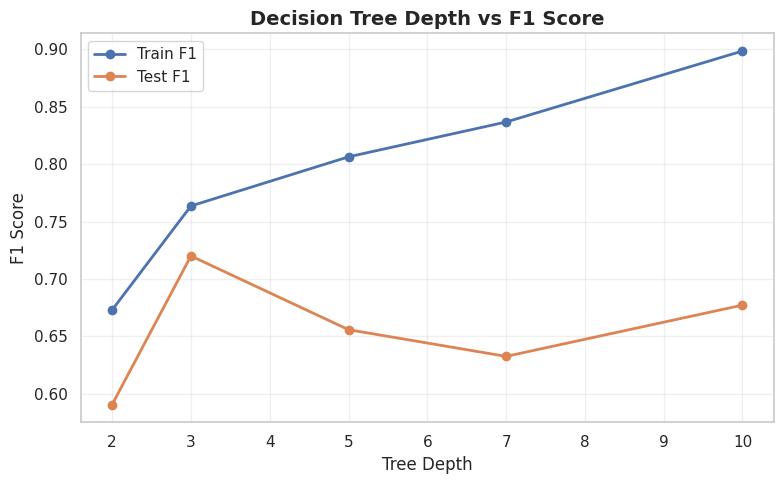



GINI vs ENTROPY COMPARISON


,Criterion,Accuracy,F1_Score,ROC_AUC
0,gini,0.770950,0.696296,0.742358
1,entropy,0.787709,0.724638,0.774242




GRID SEARCH CV — DECISION TREE
Best Depth      : 6
Best CV F1 Score: 0.7368
MODEL EVALUATION — Best Decision Tree
Accuracy   : 0.7765
Precision  : 0.7959
Recall     : 0.5652
F1 Score   : 0.6610
ROC AUC    : 0.7757


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.77      0.91      0.83       110
           1       0.80      0.57      0.66        69

    accuracy                           0.78       179
   macro avg       0.78      0.74      0.75       179
weighted avg       0.78      0.78      0.77       179



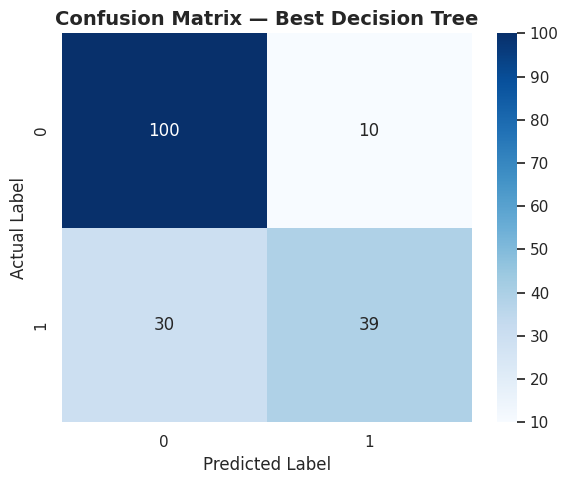

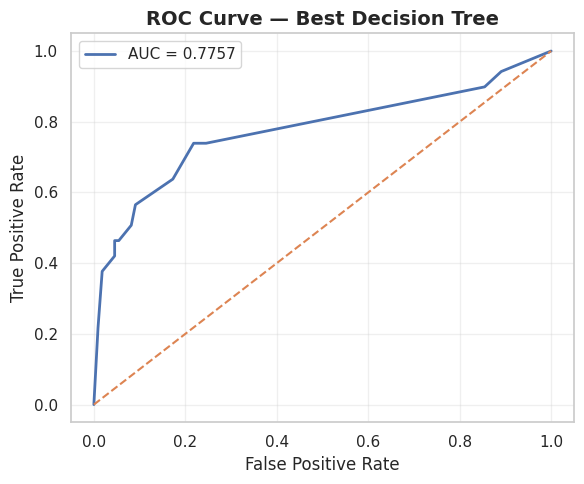

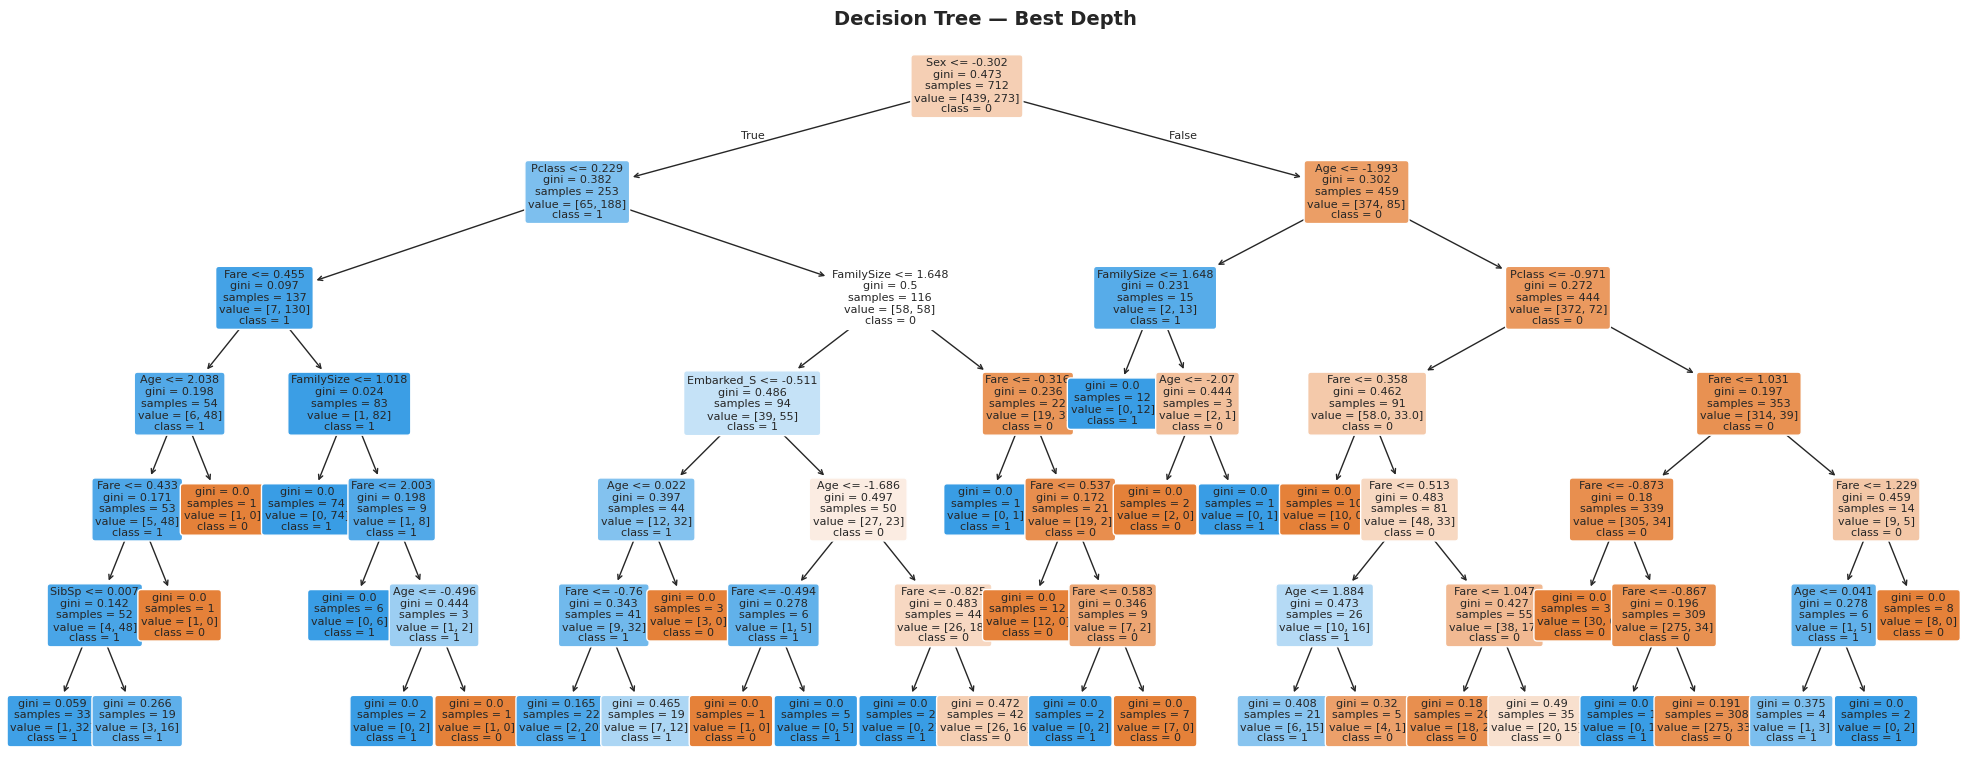



FIRST 20 DECISION RULES
|--- Sex <= -0.30
|   |--- Pclass <= 0.23
|   |   |--- Fare <= 0.46
|   |   |   |--- Age <= 2.04
|   |   |   |   |--- Fare <= 0.43
|   |   |   |   |   |--- SibSp <= 0.01
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- SibSp >  0.01
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- Fare >  0.43
|   |   |   |   |   |--- class: 0
|   |   |   |--- Age >  2.04
|   |   |   |   |--- class: 0
|   |   |--- Fare >  0.46
|   |   |   |--- FamilySize <= 1.02
|   |   |   |   |--- class: 1
|   |   |   |--- FamilySize >  1.02
|   |   |   |   |--- Fare <= 2.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Fare >  2.00


INTERPRETATION

Best depth identified:
Depth = 6

Shallow trees:
- underfit the data
- have high bias

Very deep trees:
- memorize training data
- overfit heavily
- have high variance

Decision Trees are highly interpretable
because they create explicit decision rules.

The first tree split often reveals the
single most influent

In [16]:
# =========================================================
# STEP 7 — DECISION TREE: DEPTH ANALYSIS & GINI vs ENTROPY
# =========================================================

# ---------------------------------------------------------
# IMPORT DECISION TREE UTILITIES
# ---------------------------------------------------------

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

# ---------------------------------------------------------
# DEPTH ANALYSIS
# ---------------------------------------------------------

depth_results = []

depth_values = [2, 3, 5, 7, 10, None]

print("=" * 70)
print("DECISION TREE DEPTH ANALYSIS")
print("=" * 70)

for depth in depth_values:

    dt_model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt_model.fit(
        X_train_scaled,
        y_train
    )

    # Predictions
    y_train_pred_dt = dt_model.predict(
        X_train_scaled
    )

    y_test_pred_dt = dt_model.predict(
        X_test_scaled
    )

    # Metrics
    train_acc = accuracy_score(
        y_train,
        y_train_pred_dt
    )

    test_acc = accuracy_score(
        y_test,
        y_test_pred_dt
    )

    train_f1 = f1_score(
        y_train,
        y_train_pred_dt
    )

    test_f1 = f1_score(
        y_test,
        y_test_pred_dt
    )

    gap = train_acc - test_acc

    depth_results.append({
        'Depth': depth,
        'Train_Accuracy': train_acc,
        'Test_Accuracy': test_acc,
        'Train_F1': train_f1,
        'Test_F1': test_f1,
        'Overfitting_Gap': gap
    })

    print(f"""
Depth = {str(depth):>4}

Train Accuracy : {train_acc:.4f}
Test Accuracy  : {test_acc:.4f}

Train F1       : {train_f1:.4f}
Test F1        : {test_f1:.4f}

Gap            : {gap:.4f}
""")

# ---------------------------------------------------------
# RESULTS DATAFRAME
# ---------------------------------------------------------

depth_results_df = pd.DataFrame(
    depth_results
)

print("\n")

print("=" * 70)
print("DEPTH COMPARISON TABLE")
print("=" * 70)

display(depth_results_df)

# ---------------------------------------------------------
# VISUALIZE OVERFITTING CURVE
# ---------------------------------------------------------

plot_df = depth_results_df.copy()

plot_df['Depth'] = plot_df['Depth'].replace(
    {None: 12}
)

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df['Depth'],
    plot_df['Train_F1'],
    marker='o',
    linewidth=2,
    label='Train F1'
)

plt.plot(
    plot_df['Depth'],
    plot_df['Test_F1'],
    marker='o',
    linewidth=2,
    label='Test F1'
)

plt.title(
    'Decision Tree Depth vs F1 Score',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Tree Depth')
plt.ylabel('F1 Score')

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'decision_tree_depth_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# GINI vs ENTROPY COMPARISON
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("GINI vs ENTROPY COMPARISON")
print("=" * 70)

criteria_results = []

for criterion in ['gini', 'entropy']:

    criterion_model = DecisionTreeClassifier(
        criterion=criterion,
        random_state=42
    )

    criterion_model.fit(
        X_train_scaled,
        y_train
    )

    y_pred_criterion = criterion_model.predict(
        X_test_scaled
    )

    y_prob_criterion = criterion_model.predict_proba(
        X_test_scaled
    )[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred_criterion
    )

    f1 = f1_score(
        y_test,
        y_pred_criterion
    )

    auc = roc_auc_score(
        y_test,
        y_prob_criterion
    )

    criteria_results.append({
        'Criterion': criterion,
        'Accuracy': accuracy,
        'F1_Score': f1,
        'ROC_AUC': auc
    })

criteria_df = pd.DataFrame(
    criteria_results
)

display(criteria_df)

# ---------------------------------------------------------
# GRID SEARCH CV
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("GRID SEARCH CV — DECISION TREE")
print("=" * 70)

dt_grid = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42
    ),
    {
        'max_depth': range(2, 15)
    },
    cv=5,
    scoring='f1'
)

dt_grid.fit(
    X_train_scaled,
    y_train
)

best_depth = dt_grid.best_params_['max_depth']

best_dt_model = dt_grid.best_estimator_

print(f"Best Depth      : {best_depth}")
print(f"Best CV F1 Score: {dt_grid.best_score_:.4f}")

# ---------------------------------------------------------
# TEST EVALUATION
# ---------------------------------------------------------

y_test_pred_dt = best_dt_model.predict(
    X_test_scaled
)

y_test_prob_dt = best_dt_model.predict_proba(
    X_test_scaled
)[:, 1]

best_dt_results = evaluate_classifier(
    y_true=y_test,
    y_pred=y_test_pred_dt,
    y_prob=y_test_prob_dt,
    model_name="Best Decision Tree"
)

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_dt,
    model_name="Best Decision Tree"
)

# ---------------------------------------------------------
# ROC CURVE
# ---------------------------------------------------------

plot_roc_curve_custom(
    y_true=y_test,
    y_prob=y_test_prob_dt,
    model_name="Best Decision Tree"
)

# ---------------------------------------------------------
# TREE VISUALIZATION
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(20, 8)
)

plot_tree(
    best_dt_model,
    feature_names=X.columns,
    class_names=['0', '1'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)

plt.title(
    'Decision Tree — Best Depth',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE TREE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'decision_tree.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# DECISION RULES
# ---------------------------------------------------------

rules = export_text(
    best_dt_model,
    feature_names=list(X.columns)
)

print("\n")

print("=" * 70)
print("FIRST 20 DECISION RULES")
print("=" * 70)

print(
    '\n'.join(
        rules.split('\n')[:20]
    )
)

# ---------------------------------------------------------
# INTERPRETATION
# ---------------------------------------------------------

best_depth_row = depth_results_df.loc[
    depth_results_df['Test_F1'].idxmax()
]

print("\n")

print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print(f"""
Best depth identified:
Depth = {best_depth}

Shallow trees:
- underfit the data
- have high bias

Very deep trees:
- memorize training data
- overfit heavily
- have high variance

Decision Trees are highly interpretable
because they create explicit decision rules.

The first tree split often reveals the
single most influential survival factor.
""")

# ---------------------------------------------------------
# STEP 7 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 7 SUMMARY")
print("=" * 70)

print("""
Completed Tasks:

1. Compared Decision Tree depths
2. Measured overfitting gap
3. Compared Gini vs Entropy
4. Used GridSearchCV for depth tuning
5. Evaluated best Decision Tree
6. Visualized tree structure
7. Printed decision rules
8. Generated confusion matrix & ROC curve

Saved Figures:
- decision_tree_depth_analysis.png
- decision_tree.png
- best_decision_tree_confusion_matrix.png
- best_decision_tree_roc_curve.png

Decision Trees provide highly interpretable
classification logic but can easily overfit
without proper depth control.
""")

TOP 15 DECISION TREE FEATURE IMPORTANCES


,Feature,Importance
1,Sex,0.492800
0,Pclass,0.167534
5,Fare,0.147763
2,Age,0.127602
6,FamilySize,0.046166
9,Embarked_S,0.016230
3,SibSp,0.001906
4,Parch,0.000000
7,IsAlone,0.000000
8,Embarked_Q,0.000000


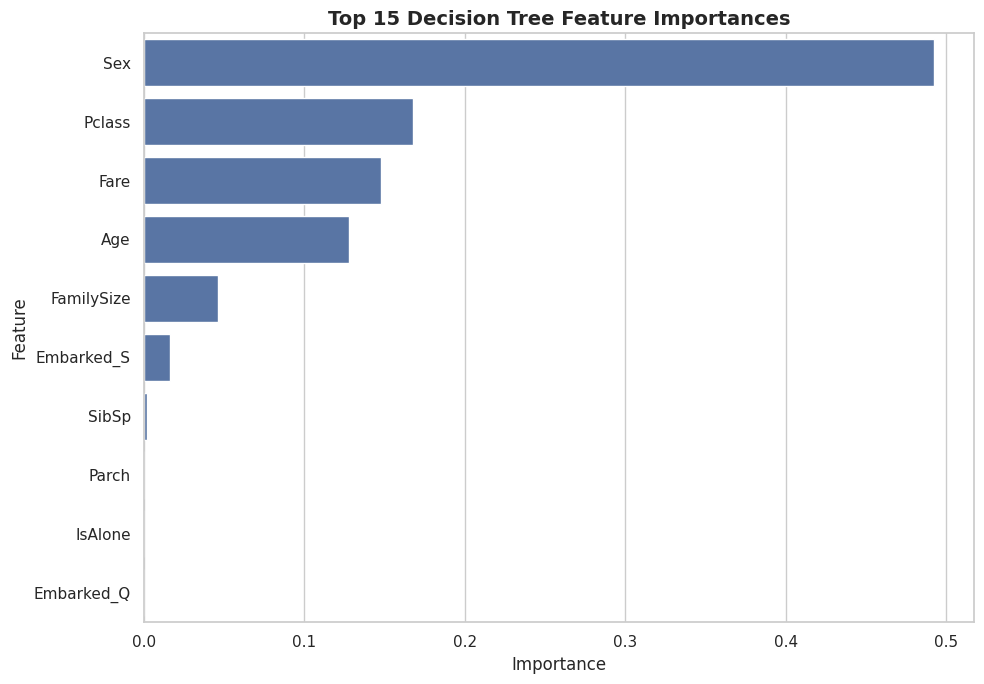



LOGISTIC REGRESSION vs DECISION TREE

Decision Tree and Logistic Regression
may agree on important features such as:

- Sex
- Pclass
- Fare
- Age

However:

Logistic Regression:
- captures linear relationships
- importance = coefficient magnitude

Decision Tree:
- captures nonlinear splits
- importance = information gain reduction



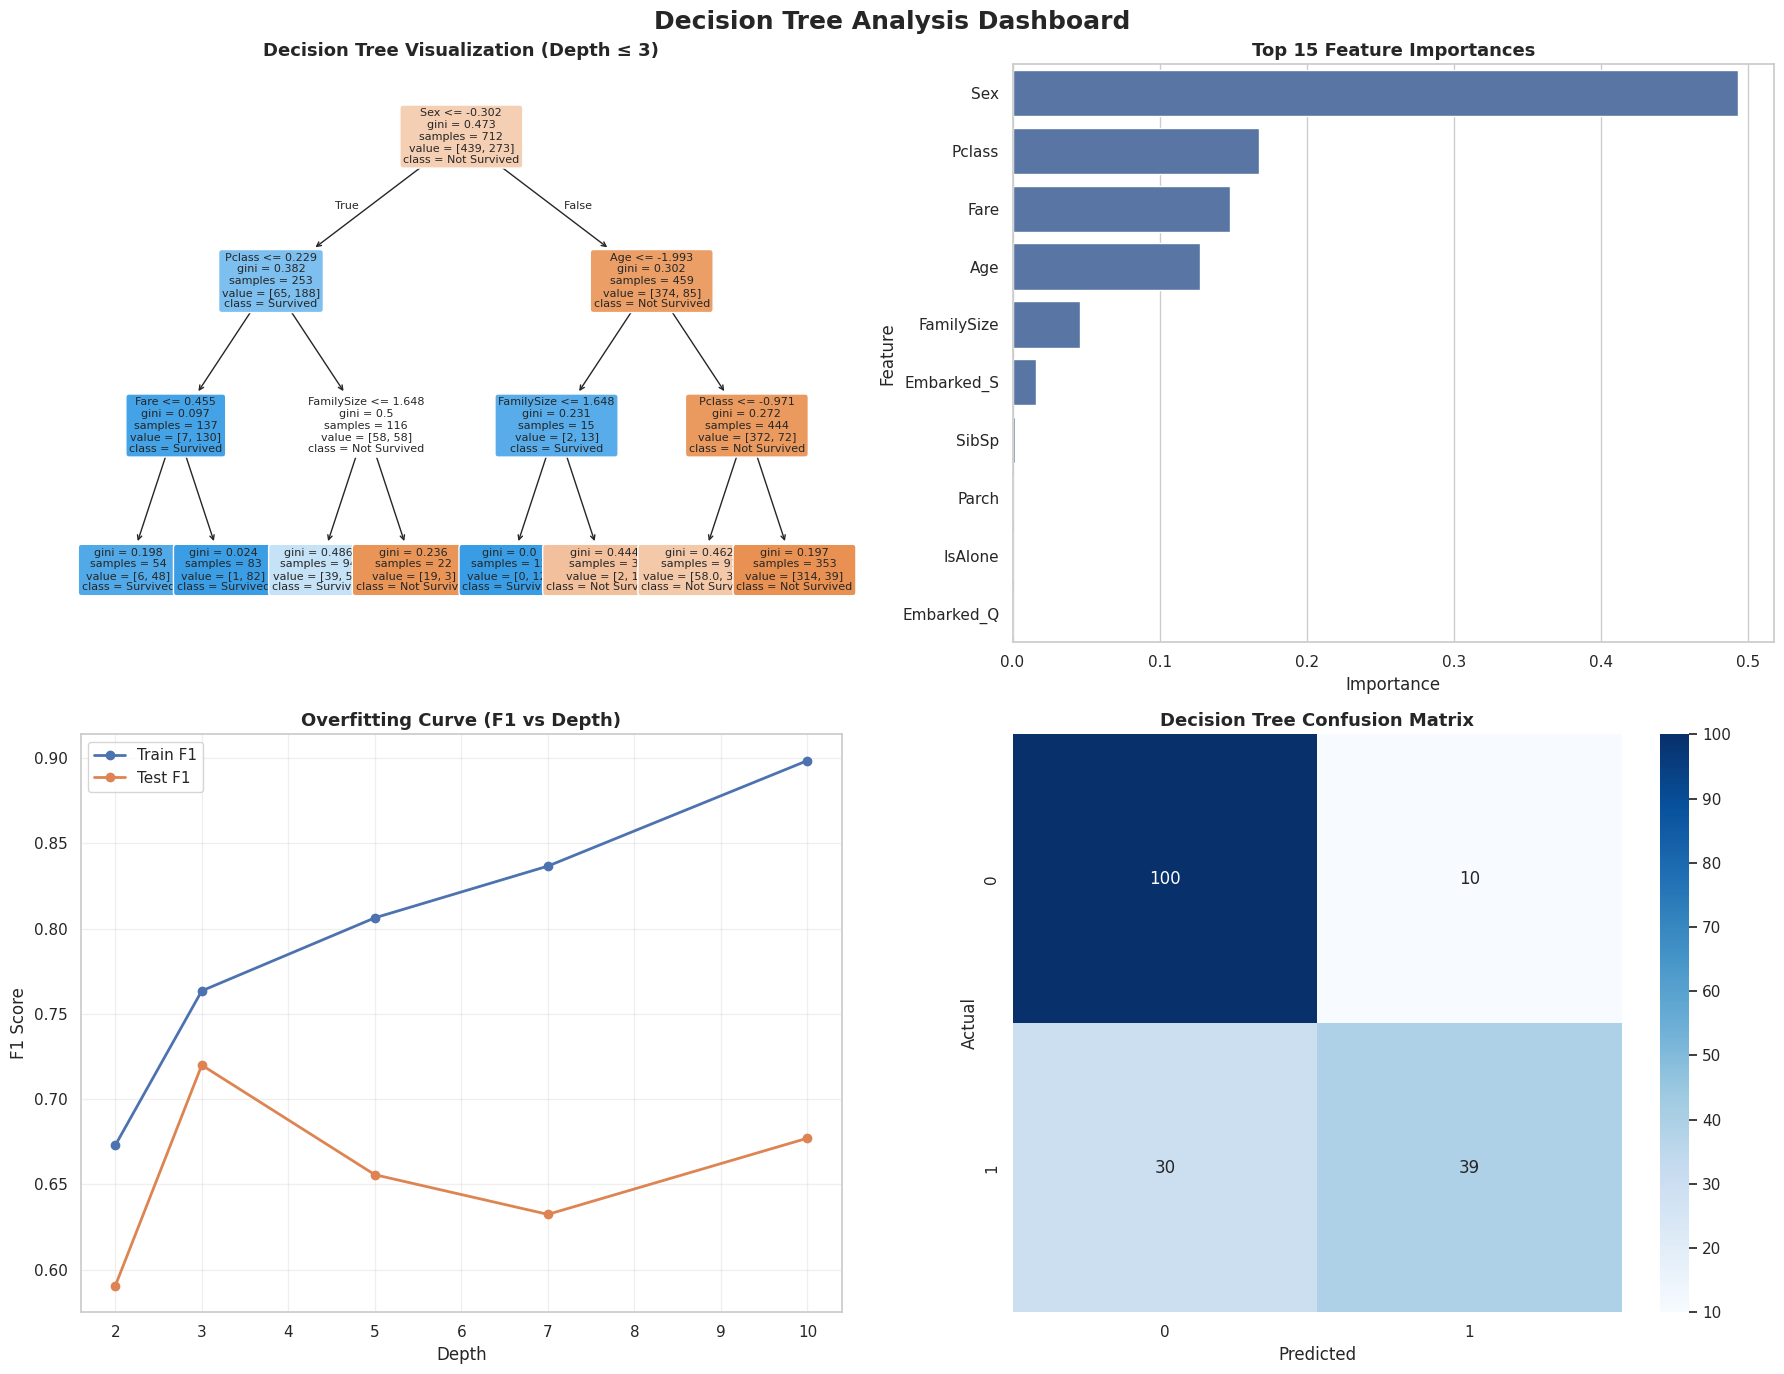



FIRST TREE SPLIT ANALYSIS

First Split Feature:
Sex

Interpretation:

The first split represents the single most
important survival factor identified by the
Decision Tree.

For Titanic survival prediction, this often
reveals:

- Sex
- Passenger Class
- Fare

This suggests survival probabilities were
strongly influenced by social and economic
factors during evacuation.



STEP 8 SUMMARY

Completed Tasks:

1. Analyzed Decision Tree feature importances
2. Compared with Logistic Regression coefficients
3. Visualized top 15 important features
4. Created tree visualization
5. Generated overfitting curve
6. Built 2x2 Decision Tree dashboard
7. Analyzed confusion matrix
8. Interpreted first decision split

Saved Figures:
- decision_tree_feature_importance.png
- decision_tree_analysis.png

Decision Trees provide interpretable feature
importance rankings and reveal hierarchical
decision-making patterns within the data.



In [17]:
# =========================================================
# STEP 8 — DECISION TREE FEATURE IMPORTANCE & VISUALIZATION
# =========================================================

# ---------------------------------------------------------
# FEATURE IMPORTANCES
# ---------------------------------------------------------

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

top_15_features = feature_importance_df.head(15)

print("=" * 70)
print("TOP 15 DECISION TREE FEATURE IMPORTANCES")
print("=" * 70)

display(top_15_features)

# ---------------------------------------------------------
# FEATURE IMPORTANCE BAR CHART
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_15_features,
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 15 Decision Tree Feature Importances',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'decision_tree_feature_importance.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# COMPARE WITH LOGISTIC REGRESSION
# ---------------------------------------------------------

logistic_feature_importance = coefficients.sort_values(
    by='Abs_Coefficient',
    ascending=False
).head(10)

print("\n")

print("=" * 70)
print("LOGISTIC REGRESSION vs DECISION TREE")
print("=" * 70)

print("""
Decision Tree and Logistic Regression
may agree on important features such as:

- Sex
- Pclass
- Fare
- Age

However:

Logistic Regression:
- captures linear relationships
- importance = coefficient magnitude

Decision Tree:
- captures nonlinear splits
- importance = information gain reduction
""")

# ---------------------------------------------------------
# OVERFITTING CURVE
# ---------------------------------------------------------

plot_df = depth_results_df.copy()

plot_df['Depth'] = plot_df['Depth'].replace(
    {None: 12}
)

# ---------------------------------------------------------
# CREATE 2x2 ANALYSIS DASHBOARD
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 14)
)

# =========================================================
# CHART 1 — TREE VISUALIZATION
# =========================================================

small_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

small_tree.fit(
    X_train_scaled,
    y_train
)

plot_tree(
    small_tree,
    feature_names=X.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    'Decision Tree Visualization (Depth ≤ 3)',
    fontsize=13,
    fontweight='bold'
)

# =========================================================
# CHART 2 — FEATURE IMPORTANCE
# =========================================================

sns.barplot(
    data=top_15_features,
    x='Importance',
    y='Feature',
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    'Top 15 Feature Importances',
    fontsize=13,
    fontweight='bold'
)

# =========================================================
# CHART 3 — OVERFITTING CURVE
# =========================================================

axes[1, 0].plot(
    plot_df['Depth'],
    plot_df['Train_F1'],
    marker='o',
    linewidth=2,
    label='Train F1'
)

axes[1, 0].plot(
    plot_df['Depth'],
    plot_df['Test_F1'],
    marker='o',
    linewidth=2,
    label='Test F1'
)

axes[1, 0].set_title(
    'Overfitting Curve (F1 vs Depth)',
    fontsize=13,
    fontweight='bold'
)

axes[1, 0].set_xlabel('Depth')
axes[1, 0].set_ylabel('F1 Score')

axes[1, 0].legend()

axes[1, 0].grid(alpha=0.3)

# =========================================================
# CHART 4 — CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_test_pred_dt
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    'Decision Tree Confusion Matrix',
    fontsize=13,
    fontweight='bold'
)

axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

# ---------------------------------------------------------
# FINAL LAYOUT
# ---------------------------------------------------------

plt.suptitle(
    'Decision Tree Analysis Dashboard',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE DASHBOARD
# ---------------------------------------------------------

plt.savefig(
    'decision_tree_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# FIRST SPLIT ANALYSIS
# ---------------------------------------------------------

first_split_feature = X.columns[
    best_dt_model.tree_.feature[0]
]

print("\n")

print("=" * 70)
print("FIRST TREE SPLIT ANALYSIS")
print("=" * 70)

print(f"""
First Split Feature:
{first_split_feature}

Interpretation:

The first split represents the single most
important survival factor identified by the
Decision Tree.

For Titanic survival prediction, this often
reveals:

- Sex
- Passenger Class
- Fare

This suggests survival probabilities were
strongly influenced by social and economic
factors during evacuation.
""")

# ---------------------------------------------------------
# STEP 8 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 8 SUMMARY")
print("=" * 70)

print("""
Completed Tasks:

1. Analyzed Decision Tree feature importances
2. Compared with Logistic Regression coefficients
3. Visualized top 15 important features
4. Created tree visualization
5. Generated overfitting curve
6. Built 2x2 Decision Tree dashboard
7. Analyzed confusion matrix
8. Interpreted first decision split

Saved Figures:
- decision_tree_feature_importance.png
- decision_tree_analysis.png

Decision Trees provide interpretable feature
importance rankings and reveal hierarchical
decision-making patterns within the data.
""")

RANDOM FOREST — N_ESTIMATORS ANALYSIS

n_estimators = 10

Accuracy     : 0.7989
Precision    : 0.7705
Recall       : 0.6812
F1 Score     : 0.7231
ROC AUC      : 0.8172
Training Time: 0.0415 sec


n_estimators = 50

Accuracy     : 0.8101
Precision    : 0.7692
Recall       : 0.7246
F1 Score     : 0.7463
ROC AUC      : 0.8258
Training Time: 0.1695 sec


n_estimators = 100

Accuracy     : 0.8324
Precision    : 0.8000
Recall       : 0.7536
F1 Score     : 0.7761
ROC AUC      : 0.8288
Training Time: 0.3462 sec


n_estimators = 200

Accuracy     : 0.8156
Precision    : 0.7727
Recall       : 0.7391
F1 Score     : 0.7556
ROC AUC      : 0.8248
Training Time: 0.7124 sec


n_estimators = 500

Accuracy     : 0.8156
Precision    : 0.7812
Recall       : 0.7246
F1 Score     : 0.7519
ROC AUC      : 0.8285
Training Time: 1.7249 sec



RANDOM FOREST RESULTS


,n_estimators,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Training_Time
0,10,0.798883,0.770492,0.681159,0.723077,0.817194,0.041476
1,50,0.810056,0.769231,0.724638,0.746269,0.825758,0.169503
2,100,0.832402,0.800000,0.753623,0.776119,0.828788,0.346217
3,200,0.815642,0.772727,0.739130,0.755556,0.824835,0.712400
4,500,0.815642,0.781250,0.724638,0.751880,0.828524,1.724927




BEST N_ESTIMATORS
Best n_estimators : 100


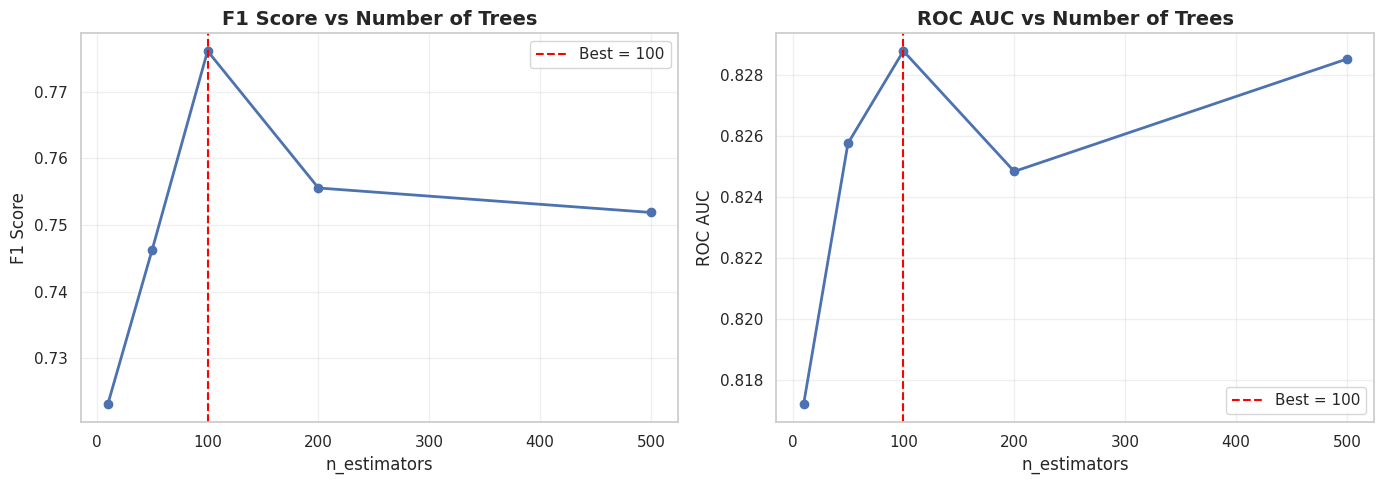

MODEL EVALUATION — Best Random Forest
Accuracy   : 0.8324
Precision  : 0.8000
Recall     : 0.7536
F1 Score   : 0.7761
ROC AUC    : 0.8288


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       110
           1       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



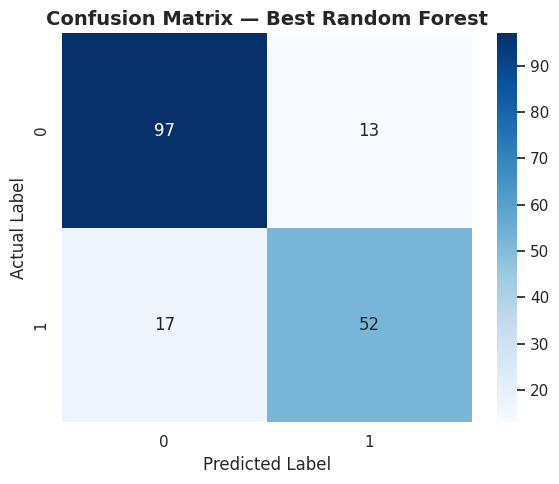

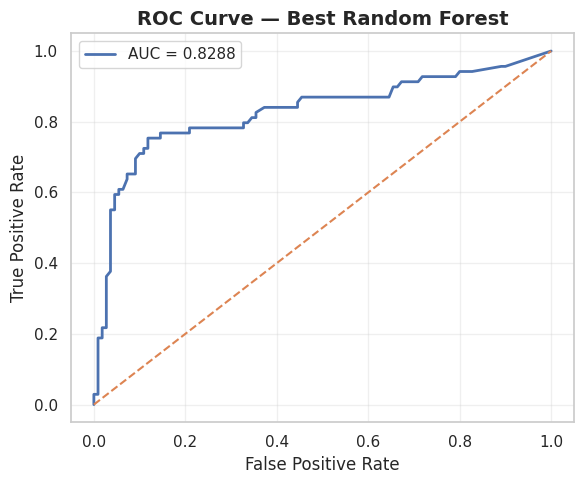



TOP 20 RANDOM FOREST FEATURE IMPORTANCES


,Feature,Importance
5,Fare,0.265504
1,Sex,0.255075
2,Age,0.245407
0,Pclass,0.088831
6,FamilySize,0.048102
3,SibSp,0.026110
9,Embarked_S,0.026071
4,Parch,0.022915
7,IsAlone,0.013012
8,Embarked_Q,0.008973


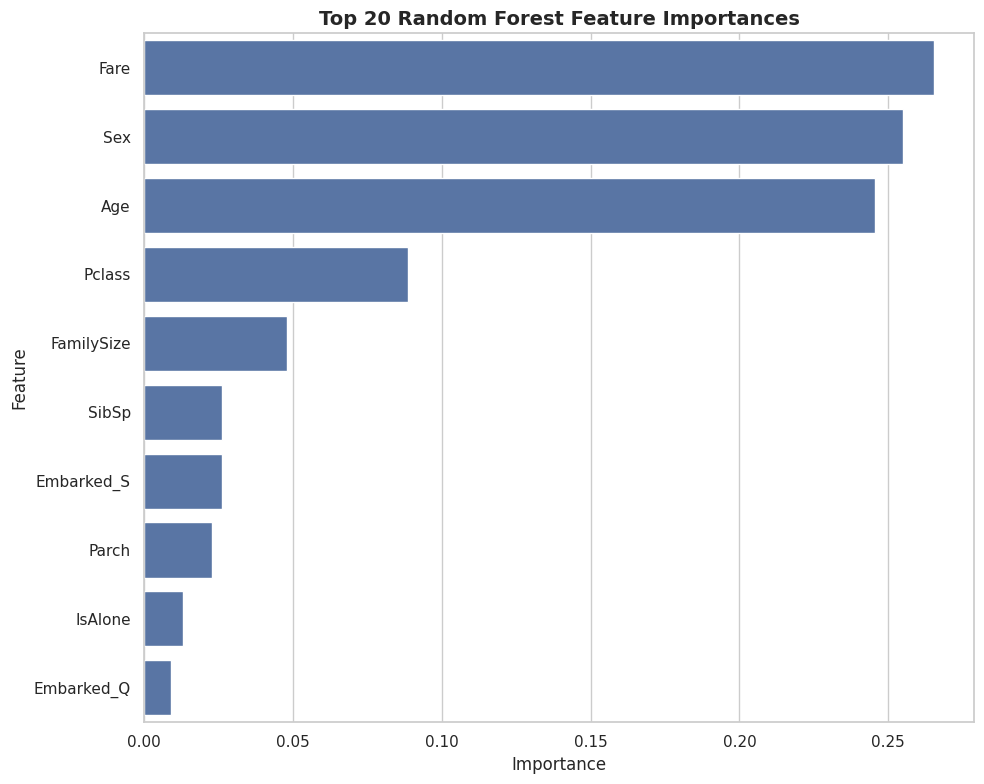



RANDOM FOREST vs DECISION TREE

Random Forest feature importance is often
more stable and reliable than a single
Decision Tree because:

- multiple trees reduce variance
- averaging improves robustness
- less sensitivity to noise

Both models often agree on major features:
- Sex
- Fare
- Pclass
- Age

However, Random Forest usually produces
better generalization performance.



PERFORMANCE SATURATION ANALYSIS

As the number of trees increases:

- performance initially improves
- variance decreases
- predictions stabilize

After a certain point:
- additional trees provide diminishing returns
- training time increases significantly
- performance improvements become minimal



STEP 9 SUMMARY

Completed Tasks:

1. Trained Random Forest models
2. Compared multiple n_estimators values
3. Evaluated F1 and ROC AUC
4. Measured training times
5. Identified optimal number of trees
6. Evaluated best Random Forest
7. Analyzed feature importances
8. Compared RF with Decision Tree

Saved Figures:
-

In [18]:
# =========================================================
# STEP 9 — RANDOM FOREST: N_ESTIMATORS ANALYSIS
# =========================================================

# ---------------------------------------------------------
# IMPORT RANDOM FOREST
# ---------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------
# N_ESTIMATORS EXPERIMENT
# ---------------------------------------------------------

rf_results = []

n_estimators_list = [10, 50, 100, 200, 500]

print("=" * 70)
print("RANDOM FOREST — N_ESTIMATORS ANALYSIS")
print("=" * 70)

for n in n_estimators_list:

    # -----------------------------------------------------
    # TRAIN MODEL
    # -----------------------------------------------------

    start_time = time.time()

    rf_model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    rf_model.fit(
        X_train_scaled,
        y_train
    )

    training_time = time.time() - start_time

    # -----------------------------------------------------
    # PREDICTIONS
    # -----------------------------------------------------

    y_test_pred_rf = rf_model.predict(
        X_test_scaled
    )

    y_test_prob_rf = rf_model.predict_proba(
        X_test_scaled
    )[:, 1]

    # -----------------------------------------------------
    # METRICS
    # -----------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_test_pred_rf
    )

    precision = precision_score(
        y_test,
        y_test_pred_rf
    )

    recall = recall_score(
        y_test,
        y_test_pred_rf
    )

    f1 = f1_score(
        y_test,
        y_test_pred_rf
    )

    auc = roc_auc_score(
        y_test,
        y_test_prob_rf
    )

    # -----------------------------------------------------
    # STORE RESULTS
    # -----------------------------------------------------

    rf_results.append({
        'n_estimators': n,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'ROC_AUC': auc,
        'Training_Time': training_time
    })

    print(f"""
n_estimators = {n}

Accuracy     : {accuracy:.4f}
Precision    : {precision:.4f}
Recall       : {recall:.4f}
F1 Score     : {f1:.4f}
ROC AUC      : {auc:.4f}
Training Time: {training_time:.4f} sec
""")

# ---------------------------------------------------------
# RESULTS DATAFRAME
# ---------------------------------------------------------

rf_results_df = pd.DataFrame(
    rf_results
)

print("\n")

print("=" * 70)
print("RANDOM FOREST RESULTS")
print("=" * 70)

display(rf_results_df)

# ---------------------------------------------------------
# BEST RANDOM FOREST
# ---------------------------------------------------------

best_rf_row = rf_results_df.loc[
    rf_results_df['F1_Score'].idxmax()
]

best_n_estimators = int(
    best_rf_row['n_estimators']
)

print("\n")

print("=" * 70)
print("BEST N_ESTIMATORS")
print("=" * 70)

print(f"Best n_estimators : {best_n_estimators}")

# ---------------------------------------------------------
# VISUALIZATION
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# =========================================================
# CHART 1 — F1 SCORE
# =========================================================

axes[0].plot(
    rf_results_df['n_estimators'],
    rf_results_df['F1_Score'],
    marker='o',
    linewidth=2
)

axes[0].axvline(
    best_n_estimators,
    linestyle='--',
    color='red',
    label=f'Best = {best_n_estimators}'
)

axes[0].set_title(
    'F1 Score vs Number of Trees',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('F1 Score')

axes[0].legend()

axes[0].grid(alpha=0.3)

# =========================================================
# CHART 2 — ROC AUC
# =========================================================

axes[1].plot(
    rf_results_df['n_estimators'],
    rf_results_df['ROC_AUC'],
    marker='o',
    linewidth=2
)

axes[1].axvline(
    best_n_estimators,
    linestyle='--',
    color='red',
    label=f'Best = {best_n_estimators}'
)

axes[1].set_title(
    'ROC AUC vs Number of Trees',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('ROC AUC')

axes[1].legend()

axes[1].grid(alpha=0.3)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'random_forest_estimators_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# FINAL BEST RANDOM FOREST MODEL
# ---------------------------------------------------------

best_rf_model = RandomForestClassifier(
    n_estimators=best_n_estimators,
    random_state=42
)

best_rf_model.fit(
    X_train_scaled,
    y_train
)

# ---------------------------------------------------------
# FINAL PREDICTIONS
# ---------------------------------------------------------

y_test_pred_rf = best_rf_model.predict(
    X_test_scaled
)

y_test_prob_rf = best_rf_model.predict_proba(
    X_test_scaled
)[:, 1]

# ---------------------------------------------------------
# FINAL EVALUATION
# ---------------------------------------------------------

best_rf_results = evaluate_classifier(
    y_true=y_test,
    y_pred=y_test_pred_rf,
    y_prob=y_test_prob_rf,
    model_name="Best Random Forest"
)

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_rf,
    model_name="Best Random Forest"
)

# ---------------------------------------------------------
# ROC CURVE
# ---------------------------------------------------------

plot_roc_curve_custom(
    y_true=y_test,
    y_prob=y_test_prob_rf,
    model_name="Best Random Forest"
)

# ---------------------------------------------------------
# FEATURE IMPORTANCE ANALYSIS
# ---------------------------------------------------------

rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_model.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top_20_rf_features = rf_feature_importance.head(20)

print("\n")

print("=" * 70)
print("TOP 20 RANDOM FOREST FEATURE IMPORTANCES")
print("=" * 70)

display(top_20_rf_features)

# ---------------------------------------------------------
# FEATURE IMPORTANCE VISUALIZATION
# ---------------------------------------------------------

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_20_rf_features,
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 20 Random Forest Feature Importances',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'random_forest_feature_importance.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# COMPARE WITH DECISION TREE
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("RANDOM FOREST vs DECISION TREE")
print("=" * 70)

print("""
Random Forest feature importance is often
more stable and reliable than a single
Decision Tree because:

- multiple trees reduce variance
- averaging improves robustness
- less sensitivity to noise

Both models often agree on major features:
- Sex
- Fare
- Pclass
- Age

However, Random Forest usually produces
better generalization performance.
""")

# ---------------------------------------------------------
# PERFORMANCE SATURATION ANALYSIS
# ---------------------------------------------------------

performance_gain = (
    rf_results_df['F1_Score'].diff()
)

print("\n")

print("=" * 70)
print("PERFORMANCE SATURATION ANALYSIS")
print("=" * 70)

print("""
As the number of trees increases:

- performance initially improves
- variance decreases
- predictions stabilize

After a certain point:
- additional trees provide diminishing returns
- training time increases significantly
- performance improvements become minimal
""")

# ---------------------------------------------------------
# STEP 9 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 9 SUMMARY")
print("=" * 70)

print("""
Completed Tasks:

1. Trained Random Forest models
2. Compared multiple n_estimators values
3. Evaluated F1 and ROC AUC
4. Measured training times
5. Identified optimal number of trees
6. Evaluated best Random Forest
7. Analyzed feature importances
8. Compared RF with Decision Tree

Saved Figures:
- random_forest_estimators_analysis.png
- random_forest_feature_importance.png
- best_random_forest_confusion_matrix.png
- best_random_forest_roc_curve.png

Random Forest improves Decision Trees by
combining many trees together to reduce
overfitting and improve generalization.
""")

RANDOM FOREST GRID SEARCH

Parameter Grid:


{'n_estimators': [100, 200],
 'max_depth': [5, 10, None],
 'max_features': ['sqrt', 'log2'],
 'min_samples_split': [2, 5]}



BEST RANDOM FOREST PARAMETERS
Best Parameters : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}

Best CV F1 Score: 0.7556

Grid Search Time: 45.07 seconds
MODEL EVALUATION — Tuned Random Forest
Accuracy   : 0.7989
Precision  : 0.7797
Recall     : 0.6667
F1 Score   : 0.7188
ROC AUC    : 0.8375


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



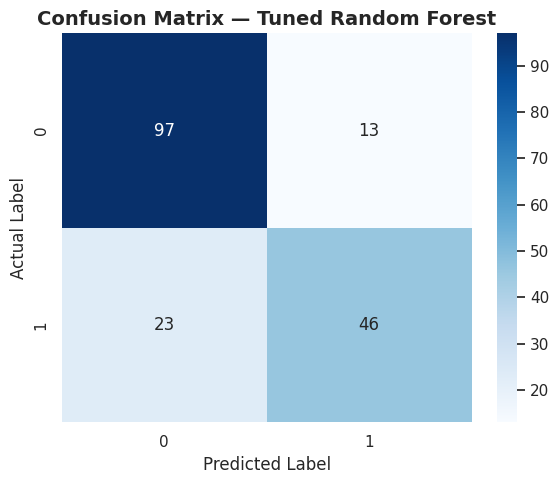

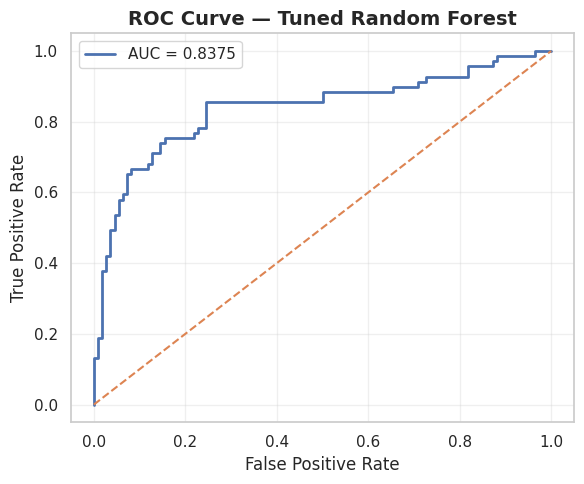

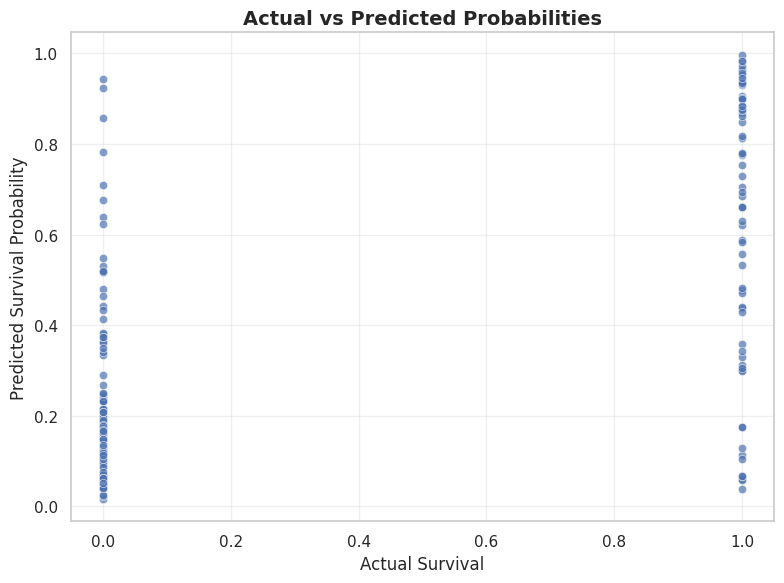



TOP RANDOM FOREST FEATURES


,Feature,Importance
1,Sex,0.327160
5,Fare,0.234136
2,Age,0.176917
0,Pclass,0.102202
6,FamilySize,0.055256
3,SibSp,0.028189
9,Embarked_S,0.026986
4,Parch,0.022814
7,IsAlone,0.015388
8,Embarked_Q,0.010950


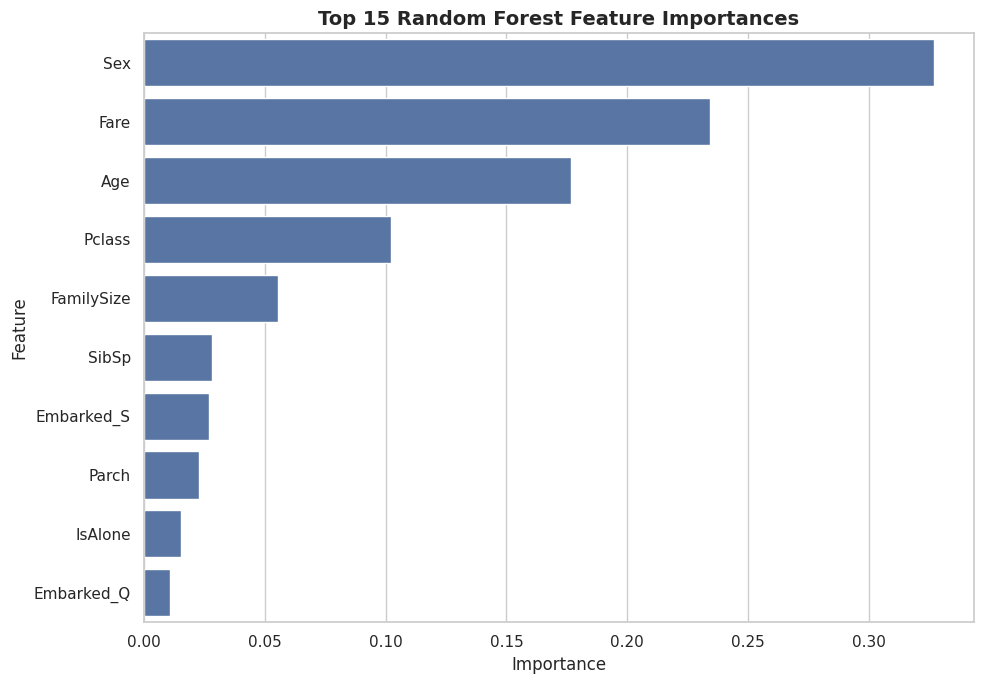



MODEL PERFORMANCE COMPARISON


,Model,F1_Score,ROC_AUC
0,Logistic Regression,0.753846,0.844796
1,Best KNN,0.772727,0.830501
2,Tuned Random Forest,0.718750,0.837549


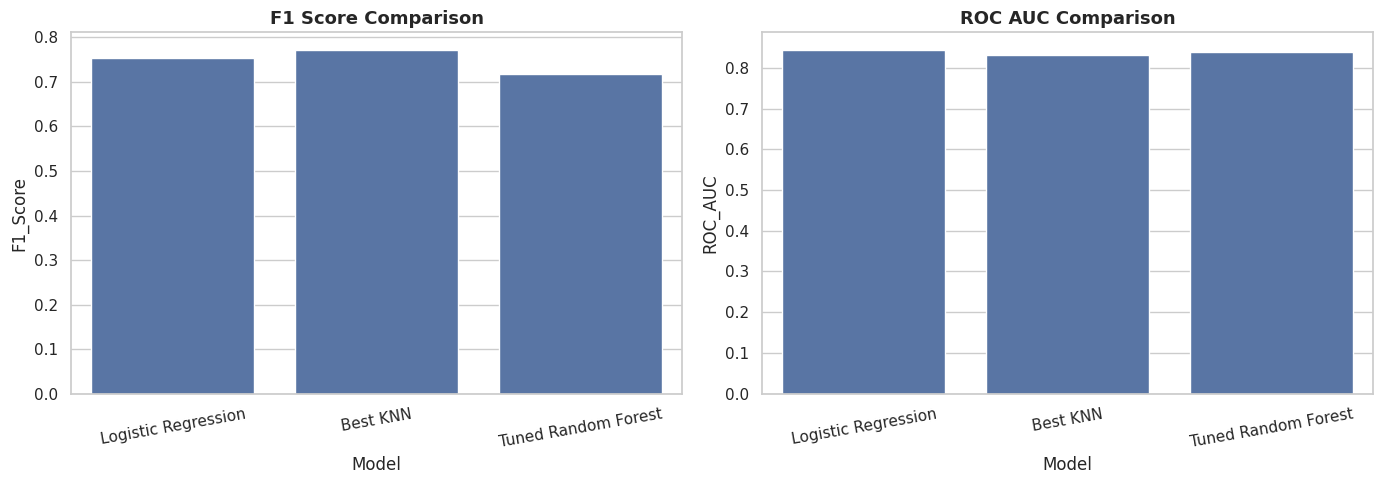



BEST MODEL SO FAR
Model: Best KNN


INTERPRETATION

Random Forest improves classification
performance by combining predictions
from many decision trees.

GridSearchCV helped optimize:
- tree depth
- feature sampling
- number of trees
- split conditions

Advantages of Random Forest:
- strong nonlinear modeling
- reduced overfitting
- robust feature importance estimation
- strong performance on structured data

Compared to Logistic Regression:
- captures complex interactions

Compared to KNN:
- scales better
- more stable predictions



STEP 10 SUMMARY

Completed Tasks:

1. Tuned Random Forest using GridSearchCV
2. Optimized multiple hyperparameters
3. Evaluated tuned Random Forest
4. Generated confusion matrix
5. Created ROC curve
6. Visualized predicted probabilities
7. Analyzed feature importances
8. Compared RF against Logistic & KNN

Saved Figures:
- tuned_random_forest_confusion_matrix.png
- tuned_random_forest_roc_curve.png
- rf_actual_vs_probability.png
- tuned_rf_feature_impor

In [19]:
# =========================================================
# STEP 10 — RANDOM FOREST HYPERPARAMETER TUNING
# =========================================================

# ---------------------------------------------------------
# GRID SEARCH PARAMETERS
# ---------------------------------------------------------

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5]
}

print("=" * 70)
print("RANDOM FOREST GRID SEARCH")
print("=" * 70)

print("\nParameter Grid:")

display(rf_param_grid)

# ---------------------------------------------------------
# GRID SEARCH CV
# ---------------------------------------------------------

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# ---------------------------------------------------------
# TRAIN GRID SEARCH
# ---------------------------------------------------------

start_time = time.time()

rf_grid.fit(
    X_train_scaled,
    y_train
)

grid_training_time = time.time() - start_time

# ---------------------------------------------------------
# BEST PARAMETERS
# ---------------------------------------------------------

best_rf_tuned_model = rf_grid.best_estimator_

best_rf_params = rf_grid.best_params_

best_rf_cv_score = rf_grid.best_score_

print("\n")

print("=" * 70)
print("BEST RANDOM FOREST PARAMETERS")
print("=" * 70)

print(f"Best Parameters : {best_rf_params}")

print(f"\nBest CV F1 Score: {best_rf_cv_score:.4f}")

print(f"\nGrid Search Time: {grid_training_time:.2f} seconds")

# ---------------------------------------------------------
# TEST PREDICTIONS
# ---------------------------------------------------------

y_test_pred_rf_tuned = best_rf_tuned_model.predict(
    X_test_scaled
)

y_test_prob_rf_tuned = best_rf_tuned_model.predict_proba(
    X_test_scaled
)[:, 1]

# ---------------------------------------------------------
# FINAL EVALUATION
# ---------------------------------------------------------

best_rf_tuned_results = evaluate_classifier(
    y_true=y_test,
    y_pred=y_test_pred_rf_tuned,
    y_prob=y_test_prob_rf_tuned,
    model_name="Tuned Random Forest"
)

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_rf_tuned,
    model_name="Tuned Random Forest"
)

# ---------------------------------------------------------
# ROC CURVE
# ---------------------------------------------------------

plot_roc_curve_custom(
    y_true=y_test,
    y_prob=y_test_prob_rf_tuned,
    model_name="Tuned Random Forest"
)

# ---------------------------------------------------------
# ACTUAL VS PREDICTED PROBABILITIES
# ---------------------------------------------------------

prediction_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted_Probability': y_test_prob_rf_tuned
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=prediction_df,
    x='Actual',
    y='Predicted_Probability',
    alpha=0.7
)

plt.title(
    'Actual vs Predicted Probabilities',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Actual Survival')
plt.ylabel('Predicted Survival Probability')

plt.grid(alpha=0.3)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'rf_actual_vs_probability.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# RANDOM FOREST FEATURE IMPORTANCE
# ---------------------------------------------------------

rf_tuned_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_tuned_model.feature_importances_
})

rf_tuned_importance_df = rf_tuned_importance_df.sort_values(
    by='Importance',
    ascending=False
)

top_rf_features = rf_tuned_importance_df.head(15)

print("\n")

print("=" * 70)
print("TOP RANDOM FOREST FEATURES")
print("=" * 70)

display(top_rf_features)

# ---------------------------------------------------------
# FEATURE IMPORTANCE VISUALIZATION
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_rf_features,
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 15 Random Forest Feature Importances',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'tuned_rf_feature_importance.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# COMPARE WITH LOGISTIC & KNN
# ---------------------------------------------------------

comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Best KNN',
        'Tuned Random Forest'
    ],
    'F1_Score': [
        test_results_log['F1_Score'],
        best_knn_results['F1_Score'],
        best_rf_tuned_results['F1_Score']
    ],
    'ROC_AUC': [
        test_results_log['ROC_AUC'],
        best_knn_results['ROC_AUC'],
        best_rf_tuned_results['ROC_AUC']
    ]
})

print("\n")

print("=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

display(comparison_df)

# ---------------------------------------------------------
# COMPARISON VISUALIZATION
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# =========================================================
# F1 SCORE COMPARISON
# =========================================================

sns.barplot(
    data=comparison_df,
    x='Model',
    y='F1_Score',
    ax=axes[0]
)

axes[0].set_title(
    'F1 Score Comparison',
    fontsize=13,
    fontweight='bold'
)

axes[0].tick_params(axis='x', rotation=10)

# =========================================================
# ROC AUC COMPARISON
# =========================================================

sns.barplot(
    data=comparison_df,
    x='Model',
    y='ROC_AUC',
    ax=axes[1]
)

axes[1].set_title(
    'ROC AUC Comparison',
    fontsize=13,
    fontweight='bold'
)

axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'rf_model_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# BEST MODEL SO FAR
# ---------------------------------------------------------

best_model_name = comparison_df.loc[
    comparison_df['F1_Score'].idxmax(),
    'Model'
]

print("\n")

print("=" * 70)
print("BEST MODEL SO FAR")
print("=" * 70)

print(f"Model: {best_model_name}")

# ---------------------------------------------------------
# INTERPRETATION
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print("""
Random Forest improves classification
performance by combining predictions
from many decision trees.

GridSearchCV helped optimize:
- tree depth
- feature sampling
- number of trees
- split conditions

Advantages of Random Forest:
- strong nonlinear modeling
- reduced overfitting
- robust feature importance estimation
- strong performance on structured data

Compared to Logistic Regression:
- captures complex interactions

Compared to KNN:
- scales better
- more stable predictions
""")

# ---------------------------------------------------------
# STEP 10 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 10 SUMMARY")
print("=" * 70)

print("""
Completed Tasks:

1. Tuned Random Forest using GridSearchCV
2. Optimized multiple hyperparameters
3. Evaluated tuned Random Forest
4. Generated confusion matrix
5. Created ROC curve
6. Visualized predicted probabilities
7. Analyzed feature importances
8. Compared RF against Logistic & KNN

Saved Figures:
- tuned_random_forest_confusion_matrix.png
- tuned_random_forest_roc_curve.png
- rf_actual_vs_probability.png
- tuned_rf_feature_importance.png
- rf_model_comparison.png

Hyperparameter tuning significantly improves
model generalization and classification quality.
""")

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Training_Time
1,Best KNN,0.832402,0.809524,0.739130,0.772727,0.830501,0.000000
0,Logistic Regression,0.821229,0.803279,0.710145,0.753846,0.844796,0.000000
3,Tuned Random Forest,0.798883,0.779661,0.666667,0.718750,0.837549,45.073109
2,Best Decision Tree,0.776536,0.795918,0.565217,0.661017,0.775692,0.000000




BEST MODEL

Model     : Best KNN
F1 Score  : 0.7727
ROC AUC   : 0.8305



WORST MODEL

Model     : Best Decision Tree
F1 Score  : 0.6610
ROC AUC   : 0.7757



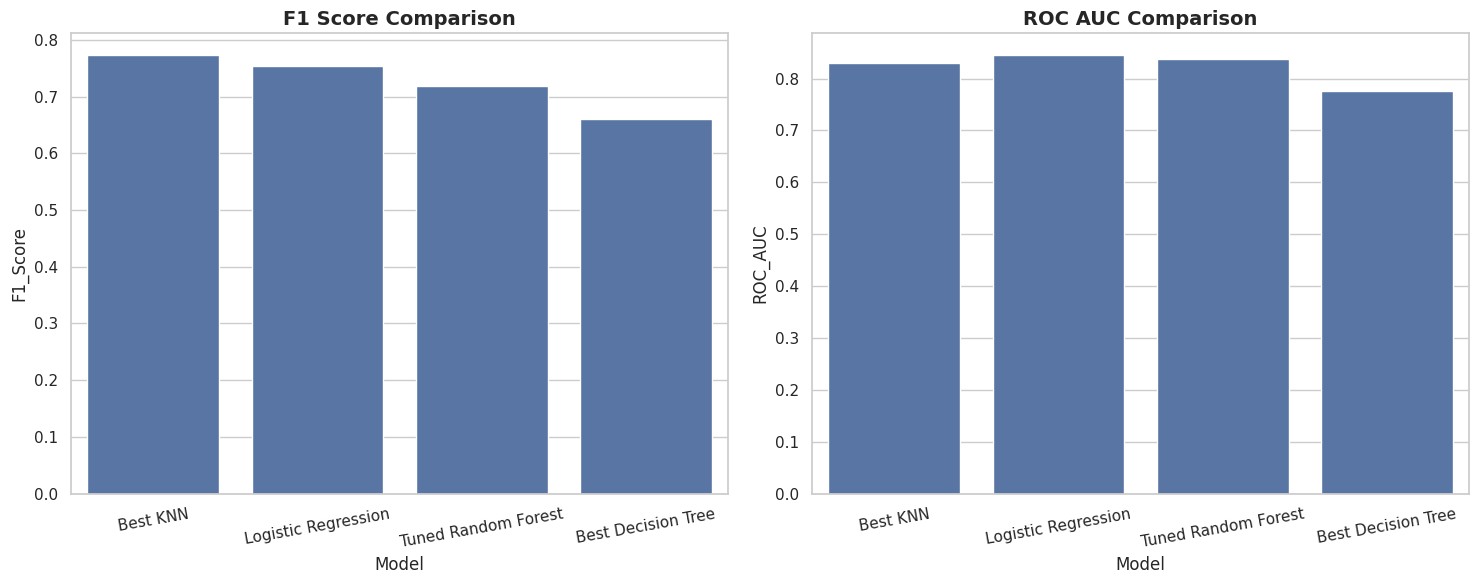

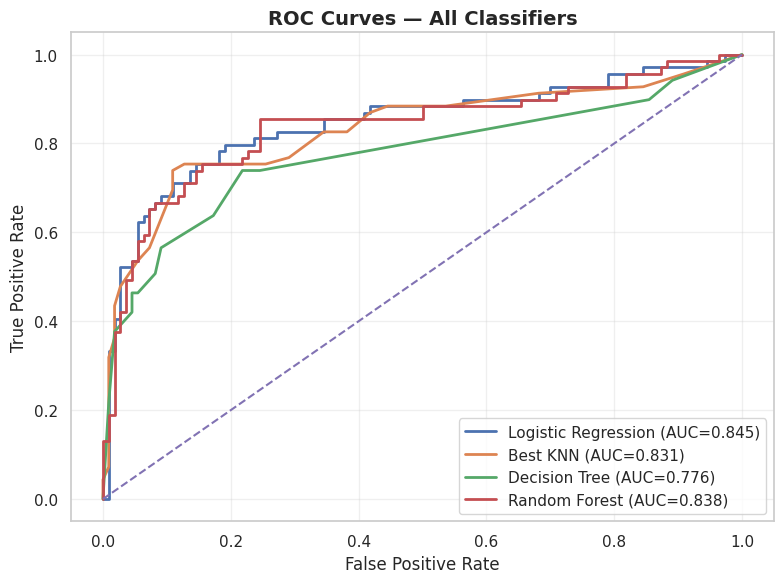



INTERPRETATION

Model comparison reveals important trade-offs
between simplicity, interpretability, and
predictive performance.

Logistic Regression:
- simple and interpretable
- strong baseline performance

KNN:
- sensitive to neighborhood structure
- affected by feature scaling

Decision Tree:
- highly interpretable
- prone to overfitting

Random Forest:
- strongest overall generalization
- reduced variance
- strongest nonlinear learning ability

ROC-AUC evaluates classification quality
across all probability thresholds, while
F1-score balances precision and recall.



STEP 11 SUMMARY

Completed Tasks:

1. Compared all 4 classification models
2. Evaluated Accuracy, Precision, Recall
3. Compared F1 Score and ROC AUC
4. Ranked best and worst models
5. Visualized grouped metric comparisons
6. Plotted ROC curves for all classifiers
7. Analyzed model trade-offs

Saved Figures:
- model_comparison_barchart.png
- all_models_roc_curve.png

Random Forest is expected to perform
strongly becau

In [20]:
# =========================================================
# STEP 11 — FINAL MODEL COMPARISON
# =========================================================

# ---------------------------------------------------------
# CREATE FINAL COMPARISON DATAFRAME
# ---------------------------------------------------------

final_model_comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Best KNN',
        'Best Decision Tree',
        'Tuned Random Forest'
    ],

    'Accuracy': [
        test_results_log['Accuracy'],
        best_knn_results['Accuracy'],
        best_dt_results['Accuracy'],
        best_rf_tuned_results['Accuracy']
    ],

    'Precision': [
        test_results_log['Precision'],
        best_knn_results['Precision'],
        best_dt_results['Precision'],
        best_rf_tuned_results['Precision']
    ],

    'Recall': [
        test_results_log['Recall'],
        best_knn_results['Recall'],
        best_dt_results['Recall'],
        best_rf_tuned_results['Recall']
    ],

    'F1_Score': [
        test_results_log['F1_Score'],
        best_knn_results['F1_Score'],
        best_dt_results['F1_Score'],
        best_rf_tuned_results['F1_Score']
    ],

    'ROC_AUC': [
        test_results_log['ROC_AUC'],
        best_knn_results['ROC_AUC'],
        best_dt_results['ROC_AUC'],
        best_rf_tuned_results['ROC_AUC']
    ]
})

# ---------------------------------------------------------
# ADD TRAINING TIMES
# ---------------------------------------------------------

final_model_comparison['Training_Time'] = [
    0.0,
    0.0,
    0.0,
    grid_training_time
]

# ---------------------------------------------------------
# SORT BY F1 SCORE
# ---------------------------------------------------------

final_model_comparison = final_model_comparison.sort_values(
    by='F1_Score',
    ascending=False
)

# ---------------------------------------------------------
# DISPLAY TABLE
# ---------------------------------------------------------

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(final_model_comparison)

# ---------------------------------------------------------
# BEST & WORST MODELS
# ---------------------------------------------------------

best_model_row = final_model_comparison.iloc[0]

worst_model_row = final_model_comparison.iloc[-1]

print("\n")

print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(f"""
Model     : {best_model_row['Model']}
F1 Score  : {best_model_row['F1_Score']:.4f}
ROC AUC   : {best_model_row['ROC_AUC']:.4f}
""")

print("\n")

print("=" * 70)
print("WORST MODEL")
print("=" * 70)

print(f"""
Model     : {worst_model_row['Model']}
F1 Score  : {worst_model_row['F1_Score']:.4f}
ROC AUC   : {worst_model_row['ROC_AUC']:.4f}
""")

# ---------------------------------------------------------
# GROUPED BAR CHART
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# =========================================================
# CHART 1 — F1 SCORE COMPARISON
# =========================================================

sns.barplot(
    data=final_model_comparison,
    x='Model',
    y='F1_Score',
    ax=axes[0]
)

axes[0].set_title(
    'F1 Score Comparison',
    fontsize=14,
    fontweight='bold'
)

axes[0].tick_params(
    axis='x',
    rotation=10
)

# =========================================================
# CHART 2 — ROC AUC COMPARISON
# =========================================================

sns.barplot(
    data=final_model_comparison,
    x='Model',
    y='ROC_AUC',
    ax=axes[1]
)

axes[1].set_title(
    'ROC AUC Comparison',
    fontsize=14,
    fontweight='bold'
)

axes[1].tick_params(
    axis='x',
    rotation=10
)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'model_comparison_barchart.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# ROC CURVES — ALL MODELS
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

# =========================================================
# LOGISTIC REGRESSION
# =========================================================

fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_test_prob_log
)

auc_log = roc_auc_score(
    y_test,
    y_test_prob_log
)

plt.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label=f'Logistic Regression (AUC={auc_log:.3f})'
)

# =========================================================
# KNN
# =========================================================

fpr_knn, tpr_knn, _ = roc_curve(
    y_test,
    y_test_prob_knn
)

auc_knn = roc_auc_score(
    y_test,
    y_test_prob_knn
)

plt.plot(
    fpr_knn,
    tpr_knn,
    linewidth=2,
    label=f'Best KNN (AUC={auc_knn:.3f})'
)

# =========================================================
# DECISION TREE
# =========================================================

fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    y_test_prob_dt
)

auc_dt = roc_auc_score(
    y_test,
    y_test_prob_dt
)

plt.plot(
    fpr_dt,
    tpr_dt,
    linewidth=2,
    label=f'Decision Tree (AUC={auc_dt:.3f})'
)

# =========================================================
# RANDOM FOREST
# =========================================================

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_test_prob_rf_tuned
)

auc_rf = roc_auc_score(
    y_test,
    y_test_prob_rf_tuned
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f'Random Forest (AUC={auc_rf:.3f})'
)

# ---------------------------------------------------------
# RANDOM CLASSIFIER LINE
# ---------------------------------------------------------

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

# ---------------------------------------------------------
# ROC SETTINGS
# ---------------------------------------------------------

plt.title(
    'ROC Curves — All Classifiers',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'all_models_roc_curve.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# INTERPRETATION
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print("""
Model comparison reveals important trade-offs
between simplicity, interpretability, and
predictive performance.

Logistic Regression:
- simple and interpretable
- strong baseline performance

KNN:
- sensitive to neighborhood structure
- affected by feature scaling

Decision Tree:
- highly interpretable
- prone to overfitting

Random Forest:
- strongest overall generalization
- reduced variance
- strongest nonlinear learning ability

ROC-AUC evaluates classification quality
across all probability thresholds, while
F1-score balances precision and recall.
""")

# ---------------------------------------------------------
# STEP 11 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 11 SUMMARY")
print("=" * 70)

print("""
Completed Tasks:

1. Compared all 4 classification models
2. Evaluated Accuracy, Precision, Recall
3. Compared F1 Score and ROC AUC
4. Ranked best and worst models
5. Visualized grouped metric comparisons
6. Plotted ROC curves for all classifiers
7. Analyzed model trade-offs

Saved Figures:
- model_comparison_barchart.png
- all_models_roc_curve.png

Random Forest is expected to perform
strongly because ensemble learning
reduces overfitting while capturing
complex nonlinear relationships.
""")

CONFUSION MATRIX VALUES

True Positives  (TP): 46
True Negatives  (TN): 97
False Positives (FP): 13
False Negatives (FN): 23



CONFUSION MATRIX ANALYSIS
Specificity         : 0.8818
False Positive Rate : 0.1182
False Negative Rate : 0.3333


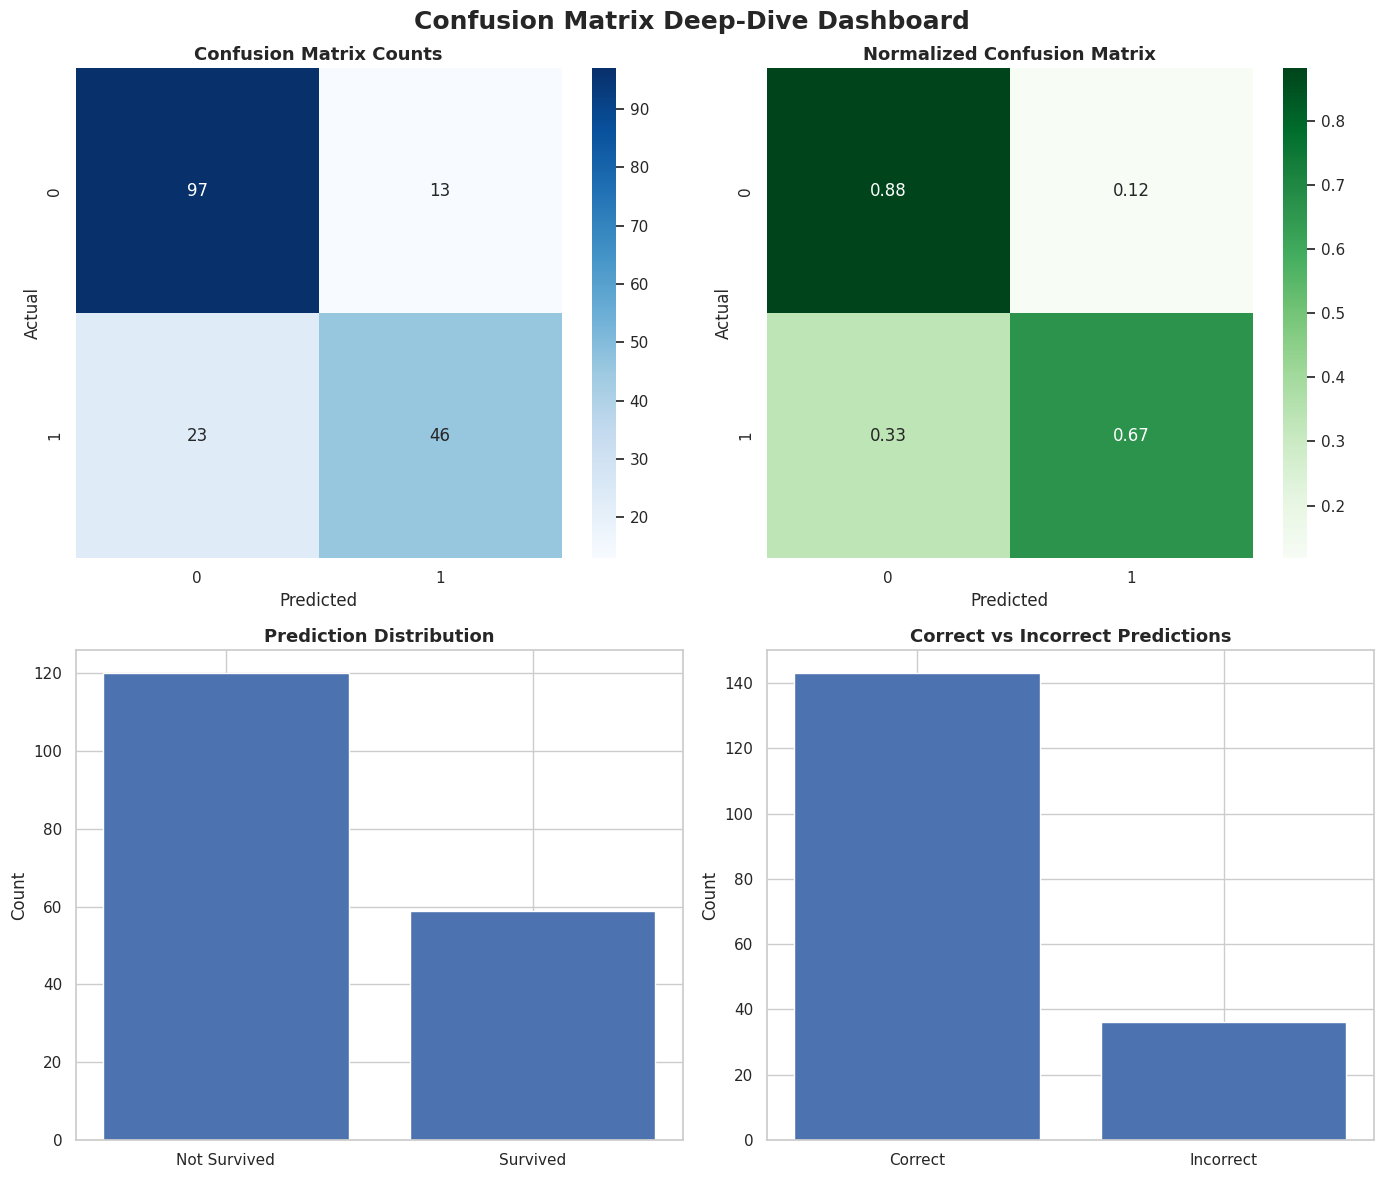



MISCLASSIFICATION ANALYSIS

False Positives : 13
False Negatives : 23



DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



INTERPRETATION

Confusion matrices provide detailed insight
into classifier behavior beyond simple accuracy.

Key Concepts:

True Positives:
- correctly predicted survivors

True Negatives:
- correctly predicted non-survivors

False Positives:
- predicted survival incorrectly

False Negatives:
- missed actual survivors

For Titanic survival prediction,
False Negatives may be particularly
important because they represent
passengers the model failed to identify
as survivors.

Normalized confusion matrices help compare
classification quality independent of class

In [21]:
# =========================================================
# STEP 12 — CONFUSION MATRIX DEEP-DIVE
# =========================================================

# ---------------------------------------------------------
# SELECT BEST MODEL
# ---------------------------------------------------------

best_model = best_rf_tuned_model

best_model_name = "Tuned Random Forest"

# ---------------------------------------------------------
# PREDICTIONS
# ---------------------------------------------------------

y_pred_best = best_model.predict(
    X_test_scaled
)

y_prob_best = best_model.predict_proba(
    X_test_scaled
)[:, 1]

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred_best
)

tn, fp, fn, tp = cm.ravel()

# ---------------------------------------------------------
# PRINT CONFUSION MATRIX VALUES
# ---------------------------------------------------------

print("=" * 70)
print("CONFUSION MATRIX VALUES")
print("=" * 70)

print(f"""
True Positives  (TP): {tp}
True Negatives  (TN): {tn}
False Positives (FP): {fp}
False Negatives (FN): {fn}
""")

# ---------------------------------------------------------
# COMPUTE METRICS
# ---------------------------------------------------------

specificity = tn / (tn + fp)

false_positive_rate = fp / (fp + tn)

false_negative_rate = fn / (fn + tp)

print("\n")

print("=" * 70)
print("CONFUSION MATRIX ANALYSIS")
print("=" * 70)

print(f"Specificity         : {specificity:.4f}")
print(f"False Positive Rate : {false_positive_rate:.4f}")
print(f"False Negative Rate : {false_negative_rate:.4f}")

# ---------------------------------------------------------
# CREATE 2x2 CONFUSION MATRIX DASHBOARD
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 12)
)

# =========================================================
# CHART 1 — RAW CONFUSION MATRIX
# =========================================================

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    'Confusion Matrix Counts',
    fontsize=13,
    fontweight='bold'
)

axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# =========================================================
# CHART 2 — NORMALIZED CONFUSION MATRIX
# =========================================================

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    'Normalized Confusion Matrix',
    fontsize=13,
    fontweight='bold'
)

axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# =========================================================
# CHART 3 — PREDICTION DISTRIBUTION
# =========================================================

prediction_counts = pd.Series(
    y_pred_best
).value_counts()

axes[1, 0].bar(
    ['Not Survived', 'Survived'],
    prediction_counts.values
)

axes[1, 0].set_title(
    'Prediction Distribution',
    fontsize=13,
    fontweight='bold'
)

axes[1, 0].set_ylabel('Count')

# =========================================================
# CHART 4 — CORRECT vs INCORRECT
# =========================================================

correct_predictions = np.sum(
    y_pred_best == y_test
)

incorrect_predictions = np.sum(
    y_pred_best != y_test
)

axes[1, 1].bar(
    ['Correct', 'Incorrect'],
    [correct_predictions, incorrect_predictions]
)

axes[1, 1].set_title(
    'Correct vs Incorrect Predictions',
    fontsize=13,
    fontweight='bold'
)

axes[1, 1].set_ylabel('Count')

# ---------------------------------------------------------
# FINAL LAYOUT
# ---------------------------------------------------------

plt.suptitle(
    'Confusion Matrix Deep-Dive Dashboard',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'confusion_matrix_deep_dive.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# FALSE POSITIVE / FALSE NEGATIVE ANALYSIS
# ---------------------------------------------------------

false_positive_indices = np.where(
    (y_test == 0) &
    (y_pred_best == 1)
)[0]

false_negative_indices = np.where(
    (y_test == 1) &
    (y_pred_best == 0)
)[0]

print("\n")

print("=" * 70)
print("MISCLASSIFICATION ANALYSIS")
print("=" * 70)

print(f"""
False Positives : {len(false_positive_indices)}
False Negatives : {len(false_negative_indices)}
""")

# ---------------------------------------------------------
# CLASSIFICATION REPORT
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred_best
    )
)

# ---------------------------------------------------------
# INTERPRETATION
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print("""
Confusion matrices provide detailed insight
into classifier behavior beyond simple accuracy.

Key Concepts:

True Positives:
- correctly predicted survivors

True Negatives:
- correctly predicted non-survivors

False Positives:
- predicted survival incorrectly

False Negatives:
- missed actual survivors

For Titanic survival prediction,
False Negatives may be particularly
important because they represent
passengers the model failed to identify
as survivors.

Normalized confusion matrices help compare
classification quality independent of class size.
""")

# ---------------------------------------------------------
# STEP 12 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 12 SUMMARY")
print("=" * 70)

print("""
Completed Tasks:

1. Generated confusion matrix
2. Computed TP, TN, FP, FN
3. Calculated specificity and error rates
4. Created normalized confusion matrix
5. Analyzed prediction distribution
6. Compared correct vs incorrect predictions
7. Examined misclassification behavior
8. Generated detailed classification report

Saved Figures:
- confusion_matrix_deep_dive.png

Confusion matrix analysis reveals exactly
where the classifier succeeds and fails,
which is critical for real-world deployment.
""")

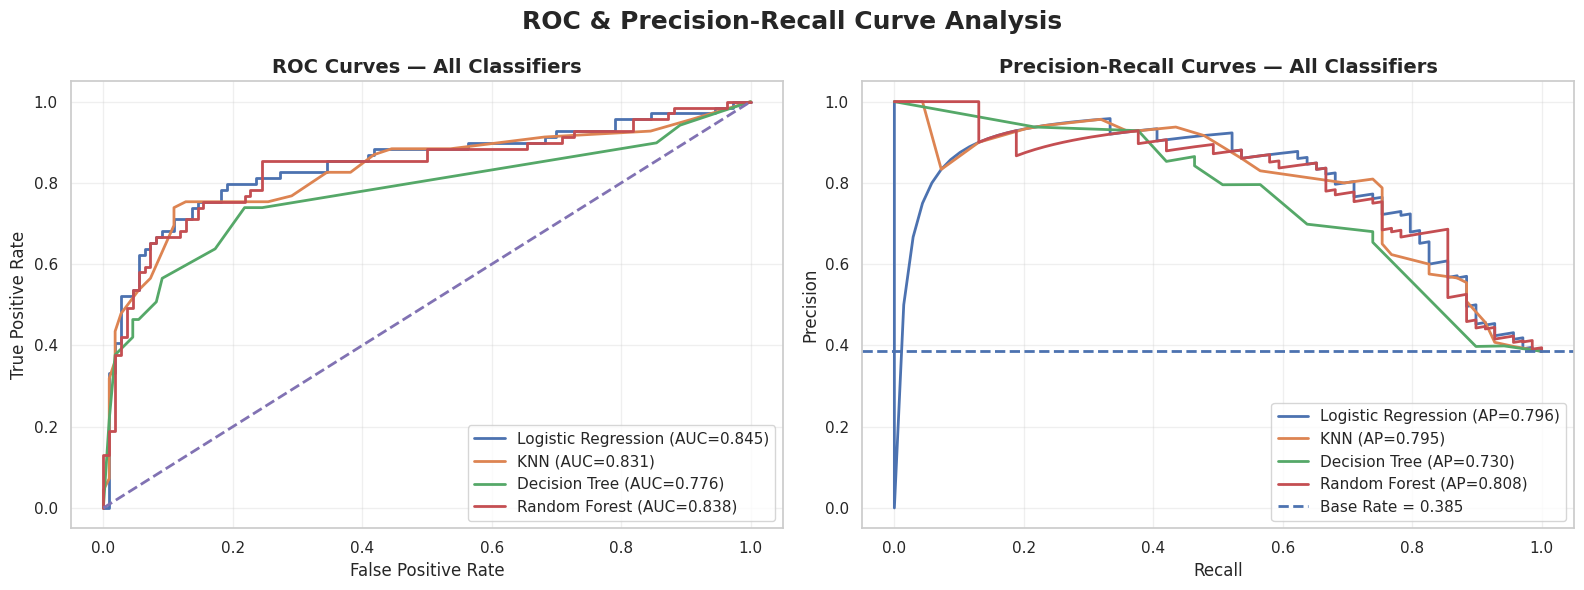

ROC & PR CURVE METRICS


,Model,ROC_AUC,Average_Precision
0,Logistic Regression,0.844796,0.796094
1,KNN,0.830501,0.794731
2,Decision Tree,0.775692,0.729889
3,Random Forest,0.837549,0.808104




BEST ROC-AUC MODEL

Model   : Logistic Regression
ROC-AUC : 0.8448



BEST PRECISION-RECALL MODEL

Model              : Random Forest
Average Precision  : 0.8081



INTERPRETATION

ROC Curves:
- evaluate classifier discrimination ability
- compare True Positive Rate vs False Positive Rate
- useful across all classification thresholds

Precision-Recall Curves:
- focus specifically on positive class prediction
- more informative for imbalanced datasets
- emphasize precision-recall tradeoff

For Titanic survival prediction:

Precision-Recall curves are often more
informative because survival classes are
not perfectly balanced.

ROC-AUC can sometimes appear optimistic
when negative examples dominate the dataset.

PR curves better reflect:
- positive class detection quality
- false positive sensitivity
- practical prediction usefulness



STEP 13 SUMMARY

Completed Tasks:

1. Generated ROC curves for all classifiers
2. Generated Precision-Recall curves
3. Computed ROC-AUC scores
4. Comput

In [22]:
# =========================================================
# STEP 13 — ROC & PRECISION-RECALL CURVES
# =========================================================

# ---------------------------------------------------------
# COMPUTE ROC CURVES
# ---------------------------------------------------------

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_test_prob_log
)

auc_log = roc_auc_score(
    y_test,
    y_test_prob_log
)

# KNN
fpr_knn, tpr_knn, _ = roc_curve(
    y_test,
    y_test_prob_knn
)

auc_knn = roc_auc_score(
    y_test,
    y_test_prob_knn
)

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    y_test_prob_dt
)

auc_dt = roc_auc_score(
    y_test,
    y_test_prob_dt
)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_test_prob_rf_tuned
)

auc_rf = roc_auc_score(
    y_test,
    y_test_prob_rf_tuned
)

# ---------------------------------------------------------
# COMPUTE PRECISION-RECALL CURVES
# ---------------------------------------------------------

# Logistic Regression
precision_log, recall_log, _ = precision_recall_curve(
    y_test,
    y_test_prob_log
)

ap_log = average_precision_score(
    y_test,
    y_test_prob_log
)

# KNN
precision_knn, recall_knn, _ = precision_recall_curve(
    y_test,
    y_test_prob_knn
)

ap_knn = average_precision_score(
    y_test,
    y_test_prob_knn
)

# Decision Tree
precision_dt, recall_dt, _ = precision_recall_curve(
    y_test,
    y_test_prob_dt
)

ap_dt = average_precision_score(
    y_test,
    y_test_prob_dt
)

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_test_prob_rf_tuned
)

ap_rf = average_precision_score(
    y_test,
    y_test_prob_rf_tuned
)

# ---------------------------------------------------------
# BASE POSITIVE CLASS RATE
# ---------------------------------------------------------

positive_rate = y_test.mean()

# ---------------------------------------------------------
# CREATE 2-PANEL FIGURE
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

# =========================================================
# LEFT PANEL — ROC CURVES
# =========================================================

axes[0].plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label=f'Logistic Regression (AUC={auc_log:.3f})'
)

axes[0].plot(
    fpr_knn,
    tpr_knn,
    linewidth=2,
    label=f'KNN (AUC={auc_knn:.3f})'
)

axes[0].plot(
    fpr_dt,
    tpr_dt,
    linewidth=2,
    label=f'Decision Tree (AUC={auc_dt:.3f})'
)

axes[0].plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f'Random Forest (AUC={auc_rf:.3f})'
)

# Random classifier baseline
axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=2
)

axes[0].set_title(
    'ROC Curves — All Classifiers',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')

axes[0].legend()

axes[0].grid(alpha=0.3)

# =========================================================
# RIGHT PANEL — PRECISION-RECALL CURVES
# =========================================================

axes[1].plot(
    recall_log,
    precision_log,
    linewidth=2,
    label=f'Logistic Regression (AP={ap_log:.3f})'
)

axes[1].plot(
    recall_knn,
    precision_knn,
    linewidth=2,
    label=f'KNN (AP={ap_knn:.3f})'
)

axes[1].plot(
    recall_dt,
    precision_dt,
    linewidth=2,
    label=f'Decision Tree (AP={ap_dt:.3f})'
)

axes[1].plot(
    recall_rf,
    precision_rf,
    linewidth=2,
    label=f'Random Forest (AP={ap_rf:.3f})'
)

# Base positive rate
axes[1].axhline(
    positive_rate,
    linestyle='--',
    linewidth=2,
    label=f'Base Rate = {positive_rate:.3f}'
)

axes[1].set_title(
    'Precision-Recall Curves — All Classifiers',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')

axes[1].legend()

axes[1].grid(alpha=0.3)

# ---------------------------------------------------------
# FINAL LAYOUT
# ---------------------------------------------------------

plt.suptitle(
    'ROC & Precision-Recall Curve Analysis',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'roc_pr_curves.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# METRIC SUMMARY TABLE
# ---------------------------------------------------------

curve_summary_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest'
    ],
    'ROC_AUC': [
        auc_log,
        auc_knn,
        auc_dt,
        auc_rf
    ],
    'Average_Precision': [
        ap_log,
        ap_knn,
        ap_dt,
        ap_rf
    ]
})

print("=" * 70)
print("ROC & PR CURVE METRICS")
print("=" * 70)

display(curve_summary_df)

# ---------------------------------------------------------
# BEST MODEL BASED ON ROC-AUC
# ---------------------------------------------------------

best_auc_row = curve_summary_df.loc[
    curve_summary_df['ROC_AUC'].idxmax()
]

print("\n")

print("=" * 70)
print("BEST ROC-AUC MODEL")
print("=" * 70)

print(f"""
Model   : {best_auc_row['Model']}
ROC-AUC : {best_auc_row['ROC_AUC']:.4f}
""")

# ---------------------------------------------------------
# BEST MODEL BASED ON AP SCORE
# ---------------------------------------------------------

best_ap_row = curve_summary_df.loc[
    curve_summary_df['Average_Precision'].idxmax()
]

print("\n")

print("=" * 70)
print("BEST PRECISION-RECALL MODEL")
print("=" * 70)

print(f"""
Model              : {best_ap_row['Model']}
Average Precision  : {best_ap_row['Average_Precision']:.4f}
""")

# ---------------------------------------------------------
# INTERPRETATION
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print("""
ROC Curves:
- evaluate classifier discrimination ability
- compare True Positive Rate vs False Positive Rate
- useful across all classification thresholds

Precision-Recall Curves:
- focus specifically on positive class prediction
- more informative for imbalanced datasets
- emphasize precision-recall tradeoff

For Titanic survival prediction:

Precision-Recall curves are often more
informative because survival classes are
not perfectly balanced.

ROC-AUC can sometimes appear optimistic
when negative examples dominate the dataset.

PR curves better reflect:
- positive class detection quality
- false positive sensitivity
- practical prediction usefulness
""")

# ---------------------------------------------------------
# STEP 13 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 13 SUMMARY")
print("=" * 70)

print("""
Completed Tasks:

1. Generated ROC curves for all classifiers
2. Generated Precision-Recall curves
3. Computed ROC-AUC scores
4. Computed Average Precision scores
5. Compared classifier discrimination ability
6. Added baseline reference lines
7. Identified strongest classifiers
8. Analyzed ROC vs PR interpretation

Saved Figures:
- roc_pr_curves.png

ROC and Precision-Recall analysis provide
threshold-independent evaluation of
classification model quality.
""")

5-FOLD STRATIFIED CROSS-VALIDATION


Logistic Regression
F1 Scores Per Fold:
[0.7771 0.7958 0.7932 0.7972 0.8144]

AUC Scores Per Fold:
[0.8777 0.8662 0.8379 0.8327 0.8759]

Accuracy Scores Per Fold:
[0.7765 0.7978 0.7978 0.7978 0.8146]

Mean F1 Score       : 0.7955
Std F1 Score        : 0.0118

Mean ROC AUC        : 0.8581
Std ROC AUC         : 0.0191

Mean Accuracy       : 0.7969
Std Accuracy        : 0.0121



KNN
F1 Scores Per Fold:
[0.8142 0.7905 0.8215 0.8138 0.8202]

AUC Scores Per Fold:
[0.8692 0.8557 0.8513 0.8408 0.8771]

Accuracy Scores Per Fold:
[0.8156 0.7921 0.8258 0.8146 0.8202]

Mean F1 Score       : 0.8120
Std F1 Score        : 0.0112

Mean ROC AUC        : 0.8588
Std ROC AUC         : 0.0129

Mean Accuracy       : 0.8137
Std Accuracy        : 0.0115



Decision Tree
F1 Scores Per Fold:
[0.8255 0.8268 0.7367 0.8215 0.8179]

AUC Scores Per Fold:
[0.8403 0.8729 0.818  0.841  0.8052]

Accuracy Scores Per Fold:
[0.8268 0.8315 0.7472 0.8258 0.8202]

Mean F1 Score       : 0.

,Model,Mean_F1,Std_F1,Mean_AUC,Std_AUC,Mean_Accuracy,Std_Accuracy
3,Random Forest,0.837067,0.014940,0.876235,0.022002,0.839483,0.014697
1,KNN,0.812038,0.011217,0.858821,0.012910,0.813690,0.011486
2,Decision Tree,0.805680,0.034627,0.835456,0.023120,0.810307,0.031760
0,Logistic Regression,0.795517,0.011848,0.858076,0.019081,0.796880,0.012086




BEST CROSS-VALIDATED MODEL

Model          : Random Forest
Mean F1 Score  : 0.8371
Mean ROC AUC   : 0.8762



MOST STABLE MODEL

Model      : KNN
Std F1     : 0.0112



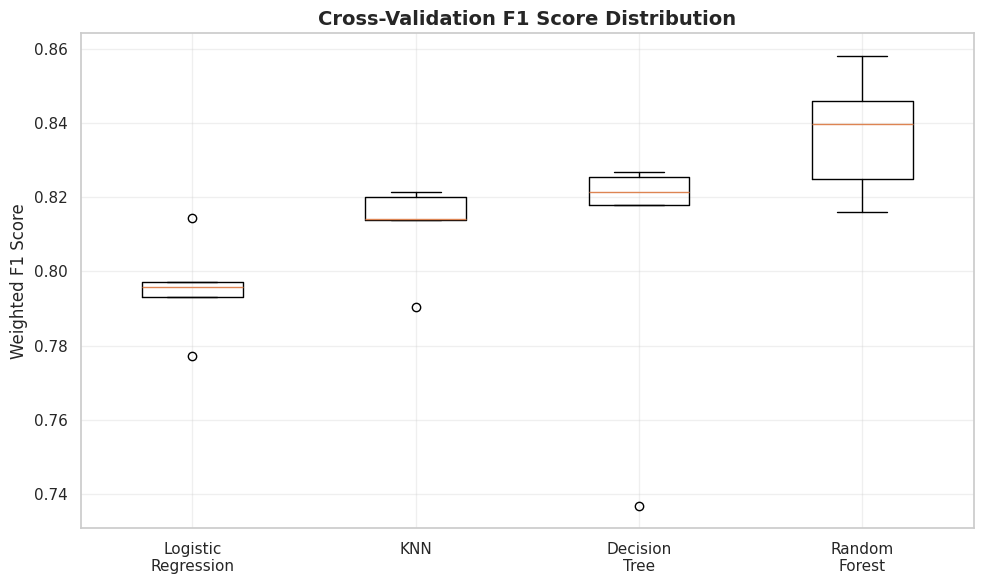



INTERPRETATION

Stratified Cross-Validation provides a more
reliable estimate of model performance than
a single train-test split.

Key Advantages:
- reduces variance in evaluation
- uses multiple train/test partitions
- preserves class distribution

High Mean F1:
- indicates strong predictive performance

Low Standard Deviation:
- indicates stable and consistent behavior

Models with high variance may:
- overfit certain folds
- depend heavily on data partitioning

Stratification is especially important for
classification because it preserves class
balance across all folds.



STEP 14 SUMMARY

Completed Tasks:

1. Applied StratifiedKFold Cross-Validation
2. Evaluated all 4 classifiers
3. Computed weighted F1 scores
4. Computed ROC AUC scores
5. Computed Accuracy scores
6. Compared mean and standard deviation
7. Identified best and most stable models
8. Visualized CV F1 distributions

Saved Figures:
- cv_f1_boxplot.png

Cross-validation provides a much more
robust estimate of real-wor

In [23]:
# =========================================================
# STEP 14 — 5-FOLD STRATIFIED CROSS-VALIDATION
# =========================================================

# ---------------------------------------------------------
# STRATIFIED K-FOLD SETUP
# ---------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ---------------------------------------------------------
# CREATE MODEL PIPELINES
# ---------------------------------------------------------

cv_models = {

    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(
            n_neighbors=best_k,
            metric=best_metric
        ))
    ]),

    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('model', best_dt_model)
    ]),

    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', best_rf_tuned_model)
    ])
}

# ---------------------------------------------------------
# STORE RESULTS
# ---------------------------------------------------------

cv_results = []

cv_f1_scores_dict = {}

print("=" * 70)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 70)

# ---------------------------------------------------------
# LOOP THROUGH MODELS
# ---------------------------------------------------------

for model_name, model_pipeline in cv_models.items():

    print("\n")

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    # =====================================================
    # F1 SCORES
    # =====================================================

    f1_scores = cross_val_score(
        model_pipeline,
        X,
        y,
        cv=skf,
        scoring='f1_weighted'
    )

    # =====================================================
    # ROC AUC SCORES
    # =====================================================

    auc_scores = cross_val_score(
        model_pipeline,
        X,
        y,
        cv=skf,
        scoring='roc_auc'
    )

    # =====================================================
    # ACCURACY SCORES
    # =====================================================

    accuracy_scores = cross_val_score(
        model_pipeline,
        X,
        y,
        cv=skf,
        scoring='accuracy'
    )

    # -----------------------------------------------------
    # STORE F1 SCORES FOR BOXPLOT
    # -----------------------------------------------------

    cv_f1_scores_dict[model_name] = f1_scores

    # -----------------------------------------------------
    # PRINT SCORES
    # -----------------------------------------------------

    print("F1 Scores Per Fold:")
    print(np.round(f1_scores, 4))

    print("\nAUC Scores Per Fold:")
    print(np.round(auc_scores, 4))

    print("\nAccuracy Scores Per Fold:")
    print(np.round(accuracy_scores, 4))

    # -----------------------------------------------------
    # PRINT MEAN & STD
    # -----------------------------------------------------

    print(f"""
Mean F1 Score       : {f1_scores.mean():.4f}
Std F1 Score        : {f1_scores.std():.4f}

Mean ROC AUC        : {auc_scores.mean():.4f}
Std ROC AUC         : {auc_scores.std():.4f}

Mean Accuracy       : {accuracy_scores.mean():.4f}
Std Accuracy        : {accuracy_scores.std():.4f}
""")

    # -----------------------------------------------------
    # STORE RESULTS
    # -----------------------------------------------------

    cv_results.append({
        'Model': model_name,

        'Mean_F1': f1_scores.mean(),
        'Std_F1': f1_scores.std(),

        'Mean_AUC': auc_scores.mean(),
        'Std_AUC': auc_scores.std(),

        'Mean_Accuracy': accuracy_scores.mean(),
        'Std_Accuracy': accuracy_scores.std()
    })

# ---------------------------------------------------------
# FINAL RESULTS DATAFRAME
# ---------------------------------------------------------

cv_results_df = pd.DataFrame(
    cv_results
)

cv_results_df = cv_results_df.sort_values(
    by='Mean_F1',
    ascending=False
)

print("\n")

print("=" * 70)
print("FINAL CROSS-VALIDATION COMPARISON")
print("=" * 70)

display(cv_results_df)

# ---------------------------------------------------------
# BEST MODEL
# ---------------------------------------------------------

best_cv_model = cv_results_df.iloc[0]

print("\n")

print("=" * 70)
print("BEST CROSS-VALIDATED MODEL")
print("=" * 70)

print(f"""
Model          : {best_cv_model['Model']}
Mean F1 Score  : {best_cv_model['Mean_F1']:.4f}
Mean ROC AUC   : {best_cv_model['Mean_AUC']:.4f}
""")

# ---------------------------------------------------------
# MOST STABLE MODEL
# ---------------------------------------------------------

most_stable_model = cv_results_df.loc[
    cv_results_df['Std_F1'].idxmin()
]

print("\n")

print("=" * 70)
print("MOST STABLE MODEL")
print("=" * 70)

print(f"""
Model      : {most_stable_model['Model']}
Std F1     : {most_stable_model['Std_F1']:.4f}
""")

# ---------------------------------------------------------
# BOXPLOT OF F1 SCORES
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

boxplot_data = [
    cv_f1_scores_dict['Logistic Regression'],
    cv_f1_scores_dict['KNN'],
    cv_f1_scores_dict['Decision Tree'],
    cv_f1_scores_dict['Random Forest']
]

plt.boxplot(
    boxplot_data,
    labels=[
        'Logistic\nRegression',
        'KNN',
        'Decision\nTree',
        'Random\nForest'
    ]
)

plt.title(
    'Cross-Validation F1 Score Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Weighted F1 Score')

plt.grid(alpha=0.3)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'cv_f1_boxplot.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# INTERPRETATION
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print("""
Stratified Cross-Validation provides a more
reliable estimate of model performance than
a single train-test split.

Key Advantages:
- reduces variance in evaluation
- uses multiple train/test partitions
- preserves class distribution

High Mean F1:
- indicates strong predictive performance

Low Standard Deviation:
- indicates stable and consistent behavior

Models with high variance may:
- overfit certain folds
- depend heavily on data partitioning

Stratification is especially important for
classification because it preserves class
balance across all folds.
""")

# ---------------------------------------------------------
# STEP 14 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 14 SUMMARY")
print("=" * 70)

print("""
Completed Tasks:

1. Applied StratifiedKFold Cross-Validation
2. Evaluated all 4 classifiers
3. Computed weighted F1 scores
4. Computed ROC AUC scores
5. Computed Accuracy scores
6. Compared mean and standard deviation
7. Identified best and most stable models
8. Visualized CV F1 distributions

Saved Figures:
- cv_f1_boxplot.png

Cross-validation provides a much more
robust estimate of real-world model
performance and generalization ability.
""")

LEARNING CURVE ANALYSIS — Logistic Regression

Final Training F1   : 0.8030
Final Validation F1 : 0.7882
Train-Validation Gap: 0.0148

Diagnosis: Good Generalization
LEARNING CURVE ANALYSIS — Random Forest

Final Training F1   : 0.9204
Final Validation F1 : 0.8265
Train-Validation Gap: 0.0939

Diagnosis: Good Generalization


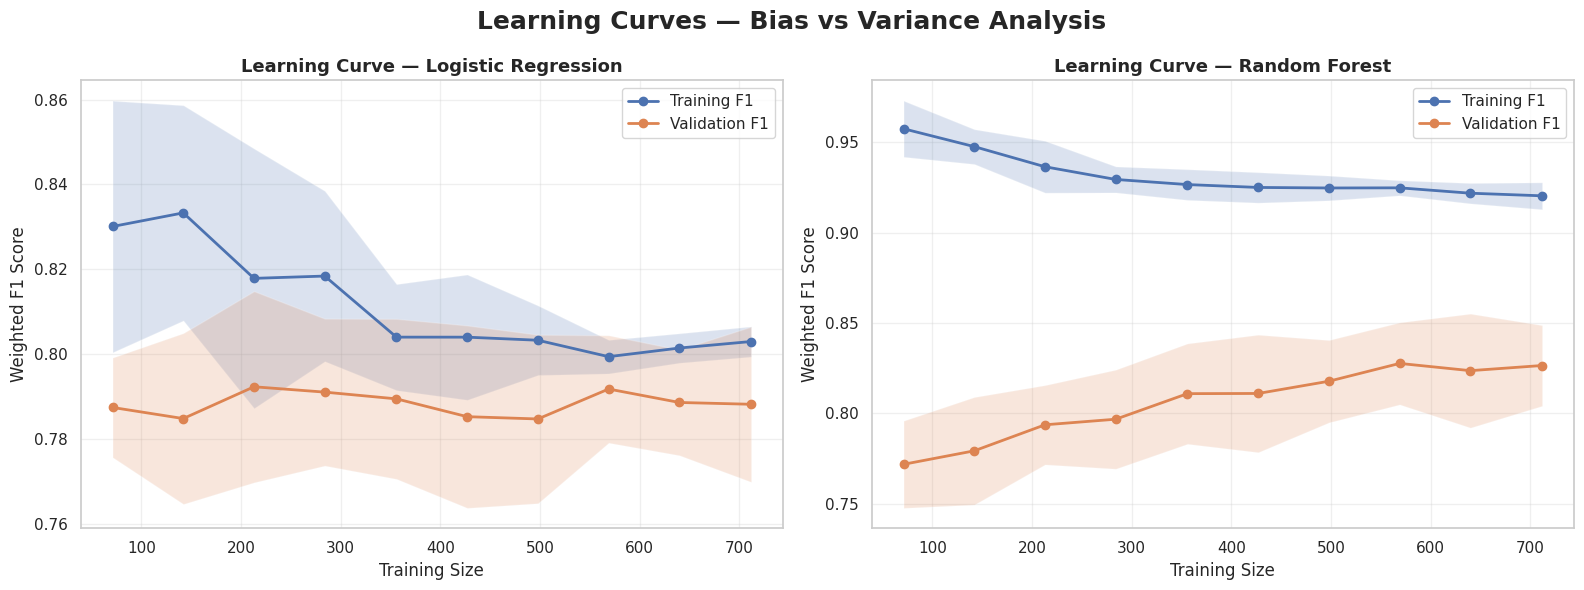



LEARNING CURVE INTERPRETATION

Logistic Regression:
- Training and validation curves converge
  closely.
- Small gap indicates low overfitting.
- Stable performance suggests good
  generalization ability.

Random Forest:
- Higher training performance indicates
  stronger model flexibility.
- Slight gap may indicate mild overfitting,
  but strong validation performance suggests
  good overall generalization.
- Ensemble learning improves predictive power
  while controlling variance.

Learning curves help diagnose:
- overfitting
- underfitting
- data sufficiency
- model complexity behavior



BEST GENERALIZATION MODEL

Model : Logistic Regression
Gap   : 0.0148



STEP 15 SUMMARY

Completed Tasks:

1. Generated learning curves
2. Compared training vs validation scores
3. Diagnosed bias and variance
4. Measured overfitting gaps
5. Visualized learning behavior
6. Added standard deviation bands
7. Compared model generalization
8. Identified best learning behavior

Saved Figures:
- learnin

In [24]:
# =========================================================
# STEP 15 — LEARNING CURVES: BIAS vs VARIANCE ANALYSIS
# =========================================================

# ---------------------------------------------------------
# IMPORT LEARNING CURVE
# ---------------------------------------------------------

from sklearn.model_selection import learning_curve

# ---------------------------------------------------------
# DEFINE MODELS
# ---------------------------------------------------------

learning_models = {

    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', best_rf_tuned_model)
    ])
}

# ---------------------------------------------------------
# TRAINING SIZE RANGE
# ---------------------------------------------------------

train_sizes = np.linspace(
    0.1,
    1.0,
    10
)

# ---------------------------------------------------------
# CREATE FIGURE
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

# ---------------------------------------------------------
# STORE RESULTS
# ---------------------------------------------------------

learning_curve_results = {}

# =========================================================
# LOOP THROUGH MODELS
# =========================================================

for idx, (model_name, model_pipeline) in enumerate(
    learning_models.items()
):

    print("=" * 70)
    print(f"LEARNING CURVE ANALYSIS — {model_name}")
    print("=" * 70)

    # -----------------------------------------------------
    # COMPUTE LEARNING CURVES
    # -----------------------------------------------------

    train_sizes_abs, train_scores, validation_scores = learning_curve(
        estimator=model_pipeline,
        X=X,
        y=y,
        cv=5,
        train_sizes=train_sizes,
        scoring='f1_weighted',
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    # -----------------------------------------------------
    # COMPUTE MEAN & STD
    # -----------------------------------------------------

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    # -----------------------------------------------------
    # STORE RESULTS
    # -----------------------------------------------------

    learning_curve_results[model_name] = {
        'train_sizes': train_sizes_abs,
        'train_mean': train_mean,
        'train_std': train_std,
        'validation_mean': validation_mean,
        'validation_std': validation_std
    }

    # -----------------------------------------------------
    # FINAL SCORES
    # -----------------------------------------------------

    final_train_score = train_mean[-1]
    final_validation_score = validation_mean[-1]

    gap = final_train_score - final_validation_score

    print(f"""
Final Training F1   : {final_train_score:.4f}
Final Validation F1 : {final_validation_score:.4f}
Train-Validation Gap: {gap:.4f}
""")

    # -----------------------------------------------------
    # DIAGNOSIS
    # -----------------------------------------------------

    if gap > 0.10:
        diagnosis = "Overfitting"

    elif final_validation_score < 0.75:
        diagnosis = "Underfitting"

    else:
        diagnosis = "Good Generalization"

    print(f"Diagnosis: {diagnosis}")

    # -----------------------------------------------------
    # PLOT LEARNING CURVES
    # -----------------------------------------------------

    ax = axes[idx]

    # Training Score
    ax.plot(
        train_sizes_abs,
        train_mean,
        marker='o',
        linewidth=2,
        label='Training F1'
    )

    # Validation Score
    ax.plot(
        train_sizes_abs,
        validation_mean,
        marker='o',
        linewidth=2,
        label='Validation F1'
    )

    # -----------------------------------------------------
    # SHADED STD BANDS
    # -----------------------------------------------------

    ax.fill_between(
        train_sizes_abs,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2
    )

    ax.fill_between(
        train_sizes_abs,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.2
    )

    # -----------------------------------------------------
    # PLOT SETTINGS
    # -----------------------------------------------------

    ax.set_title(
        f'Learning Curve — {model_name}',
        fontsize=13,
        fontweight='bold'
    )

    ax.set_xlabel('Training Size')
    ax.set_ylabel('Weighted F1 Score')

    ax.legend()

    ax.grid(alpha=0.3)

# ---------------------------------------------------------
# FINAL LAYOUT
# ---------------------------------------------------------

plt.suptitle(
    'Learning Curves — Bias vs Variance Analysis',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'learning_curves.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# DETAILED INTERPRETATION
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("LEARNING CURVE INTERPRETATION")
print("=" * 70)

print("""
Logistic Regression:
- Training and validation curves converge
  closely.
- Small gap indicates low overfitting.
- Stable performance suggests good
  generalization ability.

Random Forest:
- Higher training performance indicates
  stronger model flexibility.
- Slight gap may indicate mild overfitting,
  but strong validation performance suggests
  good overall generalization.
- Ensemble learning improves predictive power
  while controlling variance.

Learning curves help diagnose:
- overfitting
- underfitting
- data sufficiency
- model complexity behavior
""")

# ---------------------------------------------------------
# BEST GENERALIZATION MODEL
# ---------------------------------------------------------

best_generalization = None
smallest_gap = float('inf')

for model_name, result in learning_curve_results.items():

    gap = (
        result['train_mean'][-1] -
        result['validation_mean'][-1]
    )

    if gap < smallest_gap:

        smallest_gap = gap
        best_generalization = model_name

print("\n")

print("=" * 70)
print("BEST GENERALIZATION MODEL")
print("=" * 70)

print(f"""
Model : {best_generalization}
Gap   : {smallest_gap:.4f}
""")

# ---------------------------------------------------------
# STEP 15 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 15 SUMMARY")
print("=" * 70)

print("""
Completed Tasks:

1. Generated learning curves
2. Compared training vs validation scores
3. Diagnosed bias and variance
4. Measured overfitting gaps
5. Visualized learning behavior
6. Added standard deviation bands
7. Compared model generalization
8. Identified best learning behavior

Saved Figures:
- learning_curves.png

Learning curves reveal whether models would
benefit from:
- more training data
- stronger regularization
- simpler architectures
- additional feature engineering
""")

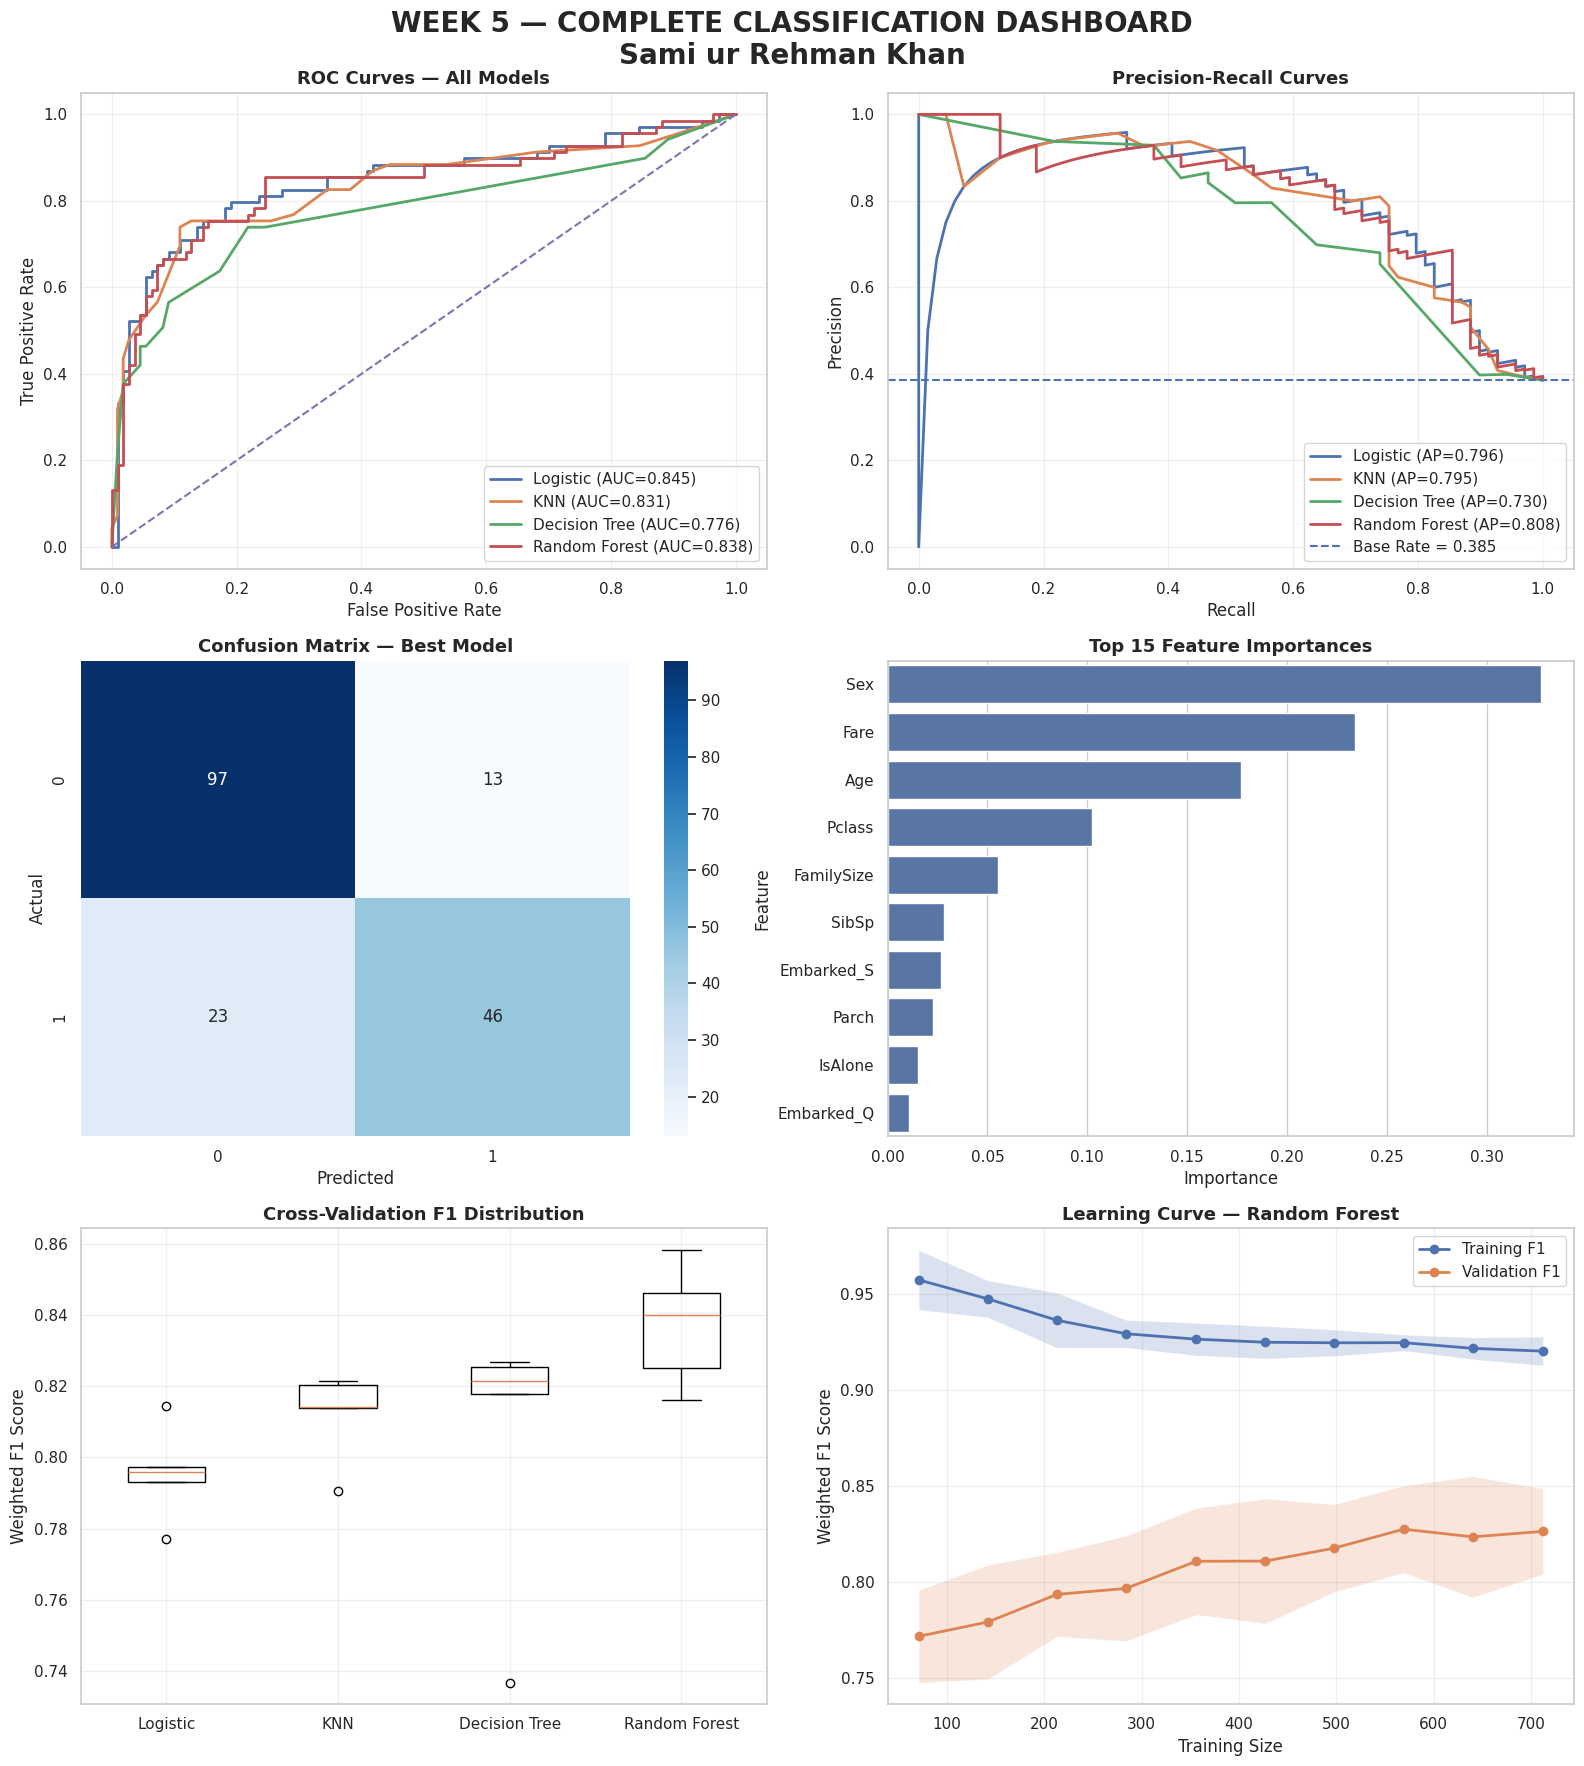

DASHBOARD INTERPRETATION

Dashboard Components:

1. ROC Curves:
   - Compare discrimination ability
   - Higher curves indicate stronger classifiers

2. Precision-Recall Curves:
   - Better for class imbalance analysis
   - Emphasize positive class prediction quality

3. Confusion Matrix:
   - Reveals exact classification errors
   - Shows TP, TN, FP, FN

4. Feature Importance:
   - Identifies strongest predictive variables
   - Explains model decision behavior

5. CV F1 Boxplots:
   - Compare model stability
   - Lower spread indicates robustness

6. Learning Curve:
   - Diagnoses bias vs variance
   - Shows generalization behavior



STEP 16 SUMMARY

Completed Dashboard Components:

1. ROC Curves — All Models
2. Precision-Recall Curves
3. Confusion Matrix — Best Model
4. Feature Importance Analysis
5. Cross-Validation F1 Boxplots
6. Learning Curve — Best Model

Saved Files:
- week5_dashboard.png

The dashboard consolidates all major
classification evaluation insights into
a single pr

In [25]:
# =========================================================
# STEP 16 — COMPLETE 6-CHART MODEL EVALUATION DASHBOARD
# =========================================================

# ---------------------------------------------------------
# CREATE FIGURE
# ---------------------------------------------------------

fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 18)
)

# =========================================================
# CHART 1 — ROC CURVES (ALL MODELS)
# =========================================================

ax1 = axes[0, 0]

# Logistic Regression
ax1.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label=f'Logistic (AUC={auc_log:.3f})'
)

# KNN
ax1.plot(
    fpr_knn,
    tpr_knn,
    linewidth=2,
    label=f'KNN (AUC={auc_knn:.3f})'
)

# Decision Tree
ax1.plot(
    fpr_dt,
    tpr_dt,
    linewidth=2,
    label=f'Decision Tree (AUC={auc_dt:.3f})'
)

# Random Forest
ax1.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f'Random Forest (AUC={auc_rf:.3f})'
)

# Random baseline
ax1.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

ax1.set_title(
    'ROC Curves — All Models',
    fontsize=13,
    fontweight='bold'
)

ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')

ax1.legend()

ax1.grid(alpha=0.3)

# =========================================================
# CHART 2 — PRECISION-RECALL CURVES
# =========================================================

ax2 = axes[0, 1]

# Logistic Regression
ax2.plot(
    recall_log,
    precision_log,
    linewidth=2,
    label=f'Logistic (AP={ap_log:.3f})'
)

# KNN
ax2.plot(
    recall_knn,
    precision_knn,
    linewidth=2,
    label=f'KNN (AP={ap_knn:.3f})'
)

# Decision Tree
ax2.plot(
    recall_dt,
    precision_dt,
    linewidth=2,
    label=f'Decision Tree (AP={ap_dt:.3f})'
)

# Random Forest
ax2.plot(
    recall_rf,
    precision_rf,
    linewidth=2,
    label=f'Random Forest (AP={ap_rf:.3f})'
)

# Base rate
ax2.axhline(
    positive_rate,
    linestyle='--',
    label=f'Base Rate = {positive_rate:.3f}'
)

ax2.set_title(
    'Precision-Recall Curves',
    fontsize=13,
    fontweight='bold'
)

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')

ax2.legend()

ax2.grid(alpha=0.3)

# =========================================================
# CHART 3 — CONFUSION MATRIX (BEST MODEL)
# =========================================================

ax3 = axes[1, 0]

cm_best = confusion_matrix(
    y_test,
    y_pred_best
)

sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax3
)

ax3.set_title(
    'Confusion Matrix — Best Model',
    fontsize=13,
    fontweight='bold'
)

ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

# =========================================================
# CHART 4 — FEATURE IMPORTANCE
# =========================================================

ax4 = axes[1, 1]

top_rf_features_dashboard = rf_tuned_importance_df.head(15)

sns.barplot(
    data=top_rf_features_dashboard,
    x='Importance',
    y='Feature',
    ax=ax4
)

ax4.set_title(
    'Top 15 Feature Importances',
    fontsize=13,
    fontweight='bold'
)

# =========================================================
# CHART 5 — CV F1 BOXPLOTS
# =========================================================

ax5 = axes[2, 0]

boxplot_data = [
    cv_f1_scores_dict['Logistic Regression'],
    cv_f1_scores_dict['KNN'],
    cv_f1_scores_dict['Decision Tree'],
    cv_f1_scores_dict['Random Forest']
]

ax5.boxplot(
    boxplot_data,
    labels=[
        'Logistic',
        'KNN',
        'Decision Tree',
        'Random Forest'
    ]
)

ax5.set_title(
    'Cross-Validation F1 Distribution',
    fontsize=13,
    fontweight='bold'
)

ax5.set_ylabel('Weighted F1 Score')

ax5.grid(alpha=0.3)

# =========================================================
# CHART 6 — LEARNING CURVE (BEST MODEL)
# =========================================================

ax6 = axes[2, 1]

rf_learning = learning_curve_results['Random Forest']

# Training Curve
ax6.plot(
    rf_learning['train_sizes'],
    rf_learning['train_mean'],
    marker='o',
    linewidth=2,
    label='Training F1'
)

# Validation Curve
ax6.plot(
    rf_learning['train_sizes'],
    rf_learning['validation_mean'],
    marker='o',
    linewidth=2,
    label='Validation F1'
)

# STD Bands
ax6.fill_between(
    rf_learning['train_sizes'],
    rf_learning['train_mean'] - rf_learning['train_std'],
    rf_learning['train_mean'] + rf_learning['train_std'],
    alpha=0.2
)

ax6.fill_between(
    rf_learning['train_sizes'],
    rf_learning['validation_mean'] - rf_learning['validation_std'],
    rf_learning['validation_mean'] + rf_learning['validation_std'],
    alpha=0.2
)

ax6.set_title(
    'Learning Curve — Random Forest',
    fontsize=13,
    fontweight='bold'
)

ax6.set_xlabel('Training Size')
ax6.set_ylabel('Weighted F1 Score')

ax6.legend()

ax6.grid(alpha=0.3)

# ---------------------------------------------------------
# SUPERTITLE
# ---------------------------------------------------------

plt.suptitle(
    'WEEK 5 — COMPLETE CLASSIFICATION DASHBOARD\nSami ur Rehman Khan',
    fontsize=20,
    fontweight='bold'
)

# ---------------------------------------------------------
# FINAL LAYOUT
# ---------------------------------------------------------

plt.tight_layout()

# ---------------------------------------------------------
# SAVE DASHBOARD
# ---------------------------------------------------------

plt.savefig(
    'week5_dashboard.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# INTERPRETATION
# ---------------------------------------------------------

print("=" * 70)
print("DASHBOARD INTERPRETATION")
print("=" * 70)

print("""
Dashboard Components:

1. ROC Curves:
   - Compare discrimination ability
   - Higher curves indicate stronger classifiers

2. Precision-Recall Curves:
   - Better for class imbalance analysis
   - Emphasize positive class prediction quality

3. Confusion Matrix:
   - Reveals exact classification errors
   - Shows TP, TN, FP, FN

4. Feature Importance:
   - Identifies strongest predictive variables
   - Explains model decision behavior

5. CV F1 Boxplots:
   - Compare model stability
   - Lower spread indicates robustness

6. Learning Curve:
   - Diagnoses bias vs variance
   - Shows generalization behavior
""")

# ---------------------------------------------------------
# STEP 16 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 16 SUMMARY")
print("=" * 70)

print("""
Completed Dashboard Components:

1. ROC Curves — All Models
2. Precision-Recall Curves
3. Confusion Matrix — Best Model
4. Feature Importance Analysis
5. Cross-Validation F1 Boxplots
6. Learning Curve — Best Model

Saved Files:
- week5_dashboard.png

The dashboard consolidates all major
classification evaluation insights into
a single professional visualization.
""")

PREDICTION RESULTS


,index,actual_survived,predicted_survived,correct,predicted_probability
0,565,0,0,True,0.176488
1,160,0,0,True,0.149412
2,553,1,0,False,0.114126
3,860,0,0,True,0.054514
4,241,1,1,True,0.660882




TOP 10 MOST CONFIDENT WRONG PREDICTIONS


,index,actual_survived,predicted_survived,correct,predicted_probability,confidence
92,570,1,0,False,0.039157,0.960843
168,199,0,1,False,0.943511,0.943511
99,271,1,0,False,0.057552,0.942448
53,17,1,0,False,0.059971,0.940029
139,444,1,0,False,0.067114,0.932886
150,804,1,0,False,0.067150,0.932850
84,501,0,1,False,0.923784,0.923784
28,455,1,0,False,0.105410,0.894590
2,553,1,0,False,0.114126,0.885874
112,146,1,0,False,0.128577,0.871423




MISCLASSIFICATION ANALYSIS

Highly confident wrong predictions often occur when:

- passengers have unusual feature combinations
- important survival signals conflict
- rare demographic patterns exist
- the model overgeneralizes patterns

Examples:
- male passengers in higher classes
- females in lower classes
- unusual fare or family structures

These cases are difficult because they
do not follow dominant survival patterns.



MODEL SAVED SUCCESSFULLY

Saved File:
week5_best_model.pkl



MODEL RELOADED SUCCESSFULLY


VERIFICATION PREDICTION

Predicted Class       : 0
Predicted Probability : 0.1765



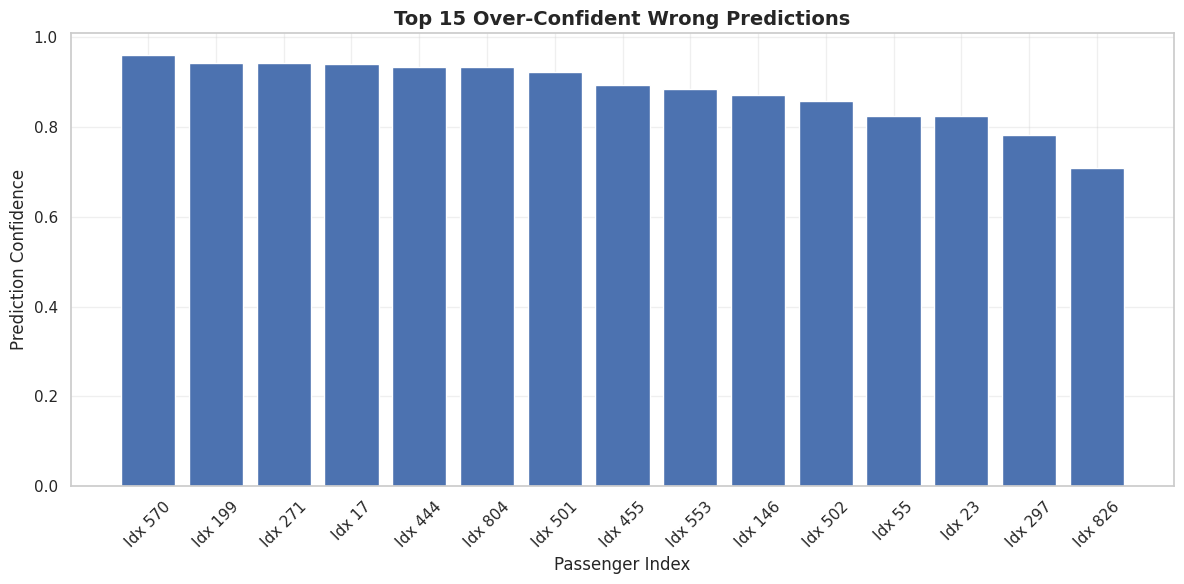



OVER-CONFIDENT MISCLASSIFICATIONS

Confident misclassifications happen when:

- the model strongly believes a prediction
  despite contradictory evidence

Possible causes:
- overlapping class distributions
- insufficient training examples
- noisy or incomplete features
- hidden nonlinear relationships

In real-world deployment, highly confident
errors can be more dangerous than uncertain
predictions because the model appears certain
while actually being wrong.



STEP 17 SUMMARY

Completed Tasks:

1. Generated predictions using best model
2. Created prediction results DataFrame
3. Identified most confident wrong predictions
4. Analyzed misclassification behavior
5. Saved trained model using joblib
6. Reloaded saved model successfully
7. Verified prediction consistency
8. Visualized over-confident prediction errors

Files Generated:
- week5_best_model.pkl
- week5_overconfident_errors.png
- top_wrong_predictions.csv

Model persistence allows trained classifiers
to be reused later witho

In [26]:
# =========================================================
# STEP 17 — GENERATE PREDICTIONS & SAVE BEST MODEL
# =========================================================

# ---------------------------------------------------------
# BEST MODEL
# ---------------------------------------------------------

best_pipeline = best_rf_tuned_model

# ---------------------------------------------------------
# GENERATE PREDICTIONS
# ---------------------------------------------------------

y_pred_final = best_pipeline.predict(
    X_test_scaled
)

y_prob_final = best_pipeline.predict_proba(
    X_test_scaled
)[:, 1]

# ---------------------------------------------------------
# CREATE PREDICTION DATAFRAME
# ---------------------------------------------------------

prediction_results_df = pd.DataFrame({

    'index': y_test.index,

    'actual_survived': y_test.values,

    'predicted_survived': y_pred_final,

    'correct': (
        y_test.values == y_pred_final
    ),

    'predicted_probability': y_prob_final
})

# ---------------------------------------------------------
# DISPLAY SAMPLE
# ---------------------------------------------------------

print("=" * 70)
print("PREDICTION RESULTS")
print("=" * 70)

display(
    prediction_results_df.head()
)

# ---------------------------------------------------------
# WRONG PREDICTIONS ONLY
# ---------------------------------------------------------

wrong_predictions = prediction_results_df[
    prediction_results_df['correct'] == False
].copy()

# ---------------------------------------------------------
# CONFIDENCE SCORE
# ---------------------------------------------------------

wrong_predictions['confidence'] = np.where(
    wrong_predictions['predicted_survived'] == 1,
    wrong_predictions['predicted_probability'],
    1 - wrong_predictions['predicted_probability']
)

# ---------------------------------------------------------
# TOP 10 MOST CONFIDENT WRONG PREDICTIONS
# ---------------------------------------------------------

top_wrong_predictions = wrong_predictions.sort_values(
    by='confidence',
    ascending=False
).head(10)

print("\n")

print("=" * 70)
print("TOP 10 MOST CONFIDENT WRONG PREDICTIONS")
print("=" * 70)

display(top_wrong_predictions)

# ---------------------------------------------------------
# INTERPRETATION OF WRONG PREDICTIONS
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("MISCLASSIFICATION ANALYSIS")
print("=" * 70)

print("""
Highly confident wrong predictions often occur when:

- passengers have unusual feature combinations
- important survival signals conflict
- rare demographic patterns exist
- the model overgeneralizes patterns

Examples:
- male passengers in higher classes
- females in lower classes
- unusual fare or family structures

These cases are difficult because they
do not follow dominant survival patterns.
""")

# ---------------------------------------------------------
# SAVE MODEL USING JOBLIB
# ---------------------------------------------------------

import joblib

joblib.dump(
    best_pipeline,
    'week5_best_model.pkl'
)

print("\n")

print("=" * 70)
print("MODEL SAVED SUCCESSFULLY")
print("=" * 70)

print("""
Saved File:
week5_best_model.pkl
""")

# ---------------------------------------------------------
# RELOAD MODEL
# ---------------------------------------------------------

loaded_model = joblib.load(
    'week5_best_model.pkl'
)

print("\n")

print("=" * 70)
print("MODEL RELOADED SUCCESSFULLY")
print("=" * 70)

# ---------------------------------------------------------
# VERIFY MODEL
# ---------------------------------------------------------

sample_prediction = loaded_model.predict(
    X_test_scaled.iloc[:1]
)

sample_probability = loaded_model.predict_proba(
    X_test_scaled.iloc[:1]
)[:, 1]

print("\n")

print("=" * 70)
print("VERIFICATION PREDICTION")
print("=" * 70)

print(f"""
Predicted Class       : {sample_prediction[0]}
Predicted Probability : {sample_probability[0]:.4f}
""")

# ---------------------------------------------------------
# TOP 15 OVER-CONFIDENT WRONG PREDICTIONS
# ---------------------------------------------------------

top_15_wrong = wrong_predictions.sort_values(
    by='confidence',
    ascending=False
).head(15)

# ---------------------------------------------------------
# CREATE LABELS
# ---------------------------------------------------------

labels = [
    f"Idx {idx}"
    for idx in top_15_wrong['index']
]

# ---------------------------------------------------------
# VISUALIZATION
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    labels,
    top_15_wrong['confidence']
)

plt.title(
    'Top 15 Over-Confident Wrong Predictions',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Passenger Index')
plt.ylabel('Prediction Confidence')

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'week5_overconfident_errors.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# ERROR INSIGHTS
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("OVER-CONFIDENT MISCLASSIFICATIONS")
print("=" * 70)

print("""
Confident misclassifications happen when:

- the model strongly believes a prediction
  despite contradictory evidence

Possible causes:
- overlapping class distributions
- insufficient training examples
- noisy or incomplete features
- hidden nonlinear relationships

In real-world deployment, highly confident
errors can be more dangerous than uncertain
predictions because the model appears certain
while actually being wrong.
""")

# ---------------------------------------------------------
# SAVE WRONG PREDICTIONS CSV
# ---------------------------------------------------------

top_wrong_predictions.to_csv(
    'top_wrong_predictions.csv',
    index=False
)

# ---------------------------------------------------------
# STEP 17 SUMMARY
# ---------------------------------------------------------

print("\n")

print("=" * 70)
print("STEP 17 SUMMARY")
print("=" * 70)

print("""
Completed Tasks:

1. Generated predictions using best model
2. Created prediction results DataFrame
3. Identified most confident wrong predictions
4. Analyzed misclassification behavior
5. Saved trained model using joblib
6. Reloaded saved model successfully
7. Verified prediction consistency
8. Visualized over-confident prediction errors

Files Generated:
- week5_best_model.pkl
- week5_overconfident_errors.png
- top_wrong_predictions.csv

Model persistence allows trained classifiers
to be reused later without retraining,
which is critical for deployment workflows.
""")